# Lab 02 MyST — Equipo 2 (Nivel C): análisis

Este notebook **no contiene lógica**: solo importa de `src/`, lee los archivos que genera `python main.py` en `docs/resultados/` y muestra las figuras de `src/plots.py`. Para regenerar todo: `python main.py`.

In [1]:
import json
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import pandas as pd
from IPython.display import Image, Markdown, display

from src import config, plots

RES, FIG = config.RESULTS_DIR, config.FIGURES_DIR
def show(name):
    display(Image(filename=str(FIG / name), width=900))

def read(name, **kw):
    return pd.read_csv(RES / name, **kw)

def read_json(name):
    return json.loads((RES / name).read_text(encoding="utf-8"))

plots.make_all_figures(RES, FIG);

## Resumen de cómputo y walk-forward

In [2]:
opt = read_json("optimizacion_resumen.json")
lock = RES / "test_lock.json"
commit = read_json("test_lock.json")["commit"] if lock.exists() else "Pendiente"
display(Markdown(
    f"- **Configuraciones evaluadas (trials totales):** {opt['configuraciones_evaluadas']:,}\n"
    f"- **Tiempo total de optimización:** {opt['segundos_optimizacion'] / 60:.1f} minutos\n"
    f"- **Variante elegida:** {opt['variante_elegida']}\n"
    f"- **WFE rolling:** {opt['wfe_rolling']['wfe_cagr']:.2f} (Calmar: {opt['wfe_rolling']['wfe_calmar']:.2f})\n"
    f"- **WFE anchored:** {opt['wfe_anclado']['wfe_cagr']:.2f} (Calmar: {opt['wfe_anclado']['wfe_calmar']:.2f})\n"
    f"- **Commit del TEST:** {commit}"))

- **Configuraciones evaluadas (trials totales):** 460,800
- **Tiempo total de optimización:** 63.1 minutos
- **Variante elegida:** por_activo
- **WFE rolling:** -0.07 (Calmar: -0.01)
- **WFE anchored:** -0.31 (Calmar: -0.05)
- **Commit del TEST:** Pendiente

## 1. Datos

In [3]:
display(read("auditoria_datos.csv"))
display(pd.Series(read_json("splits.json")))

,ticker,primera_fecha,ultima_fecha,dias_con_datos,fechas_faltantes_vs_calendario,nans_en_filas_presentes,duplicados,violaciones_high,violaciones_low,precios_no_positivos,volumen_no_positivo,n_rend_extremos,rend_extremos,completo_y_traslapado
0,NVDA,2015-01-02,2026-08-31,2932,0,0,0,0,0,0,0,1,2016-11-11:+29.8%,True
1,AMZN,2015-01-02,2026-08-31,2932,0,0,0,0,0,0,0,0,NaN,True
2,TSLA,2015-01-02,2026-08-31,2932,0,0,0,0,0,0,0,0,NaN,True
3,META,2015-01-02,2026-08-31,2932,0,0,0,0,0,0,0,1,2022-02-03:-26.4%,True
4,NFLX,2015-01-02,2026-08-31,2932,0,0,0,0,0,0,0,1,2022-04-20:-35.1%,True
5,GOOGL,2015-01-02,2026-08-31,2932,0,0,0,0,0,0,0,0,NaN,True


train_inicio                  2015-01-02
train_fin                     2024-04-26
test_inicio                   2024-04-29
test_fin                      2026-08-31
dias_train                          2345
dias_test                            587
fraccion_train                       0.8
fechas_eliminadas_limpieza             0
dtype: object

Los rendimientos extremos (> 25%) son eventos reales de resultados trimestrales; no hay faltantes ni violaciones OHLC. TRAIN = primer 80%, TEST = último 20%.

## 2. Estrategia

,activo,ema_rsi,ema_bb,rsi_bb
0,NVDA,-0.325602,-0.060630,0.257778
1,AMZN,-0.503182,-0.204751,0.445636
2,TSLA,-0.339948,-0.304370,0.442329
3,META,-0.481875,-0.096224,0.377352
4,NFLX,-0.278167,-0.047679,0.347833
5,GOOGL,-0.386879,-0.075869,0.316401


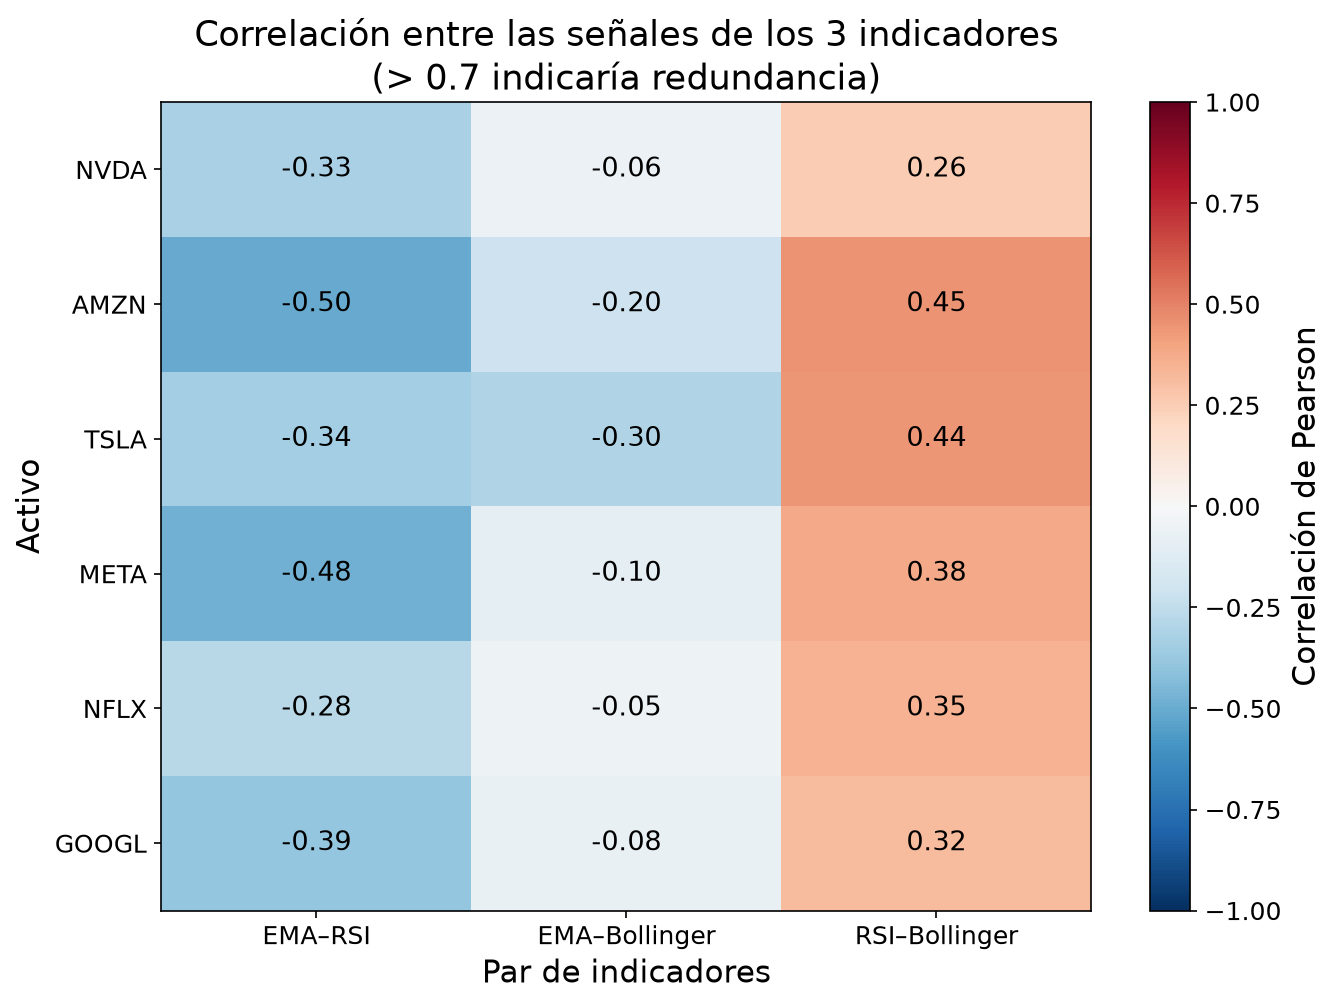

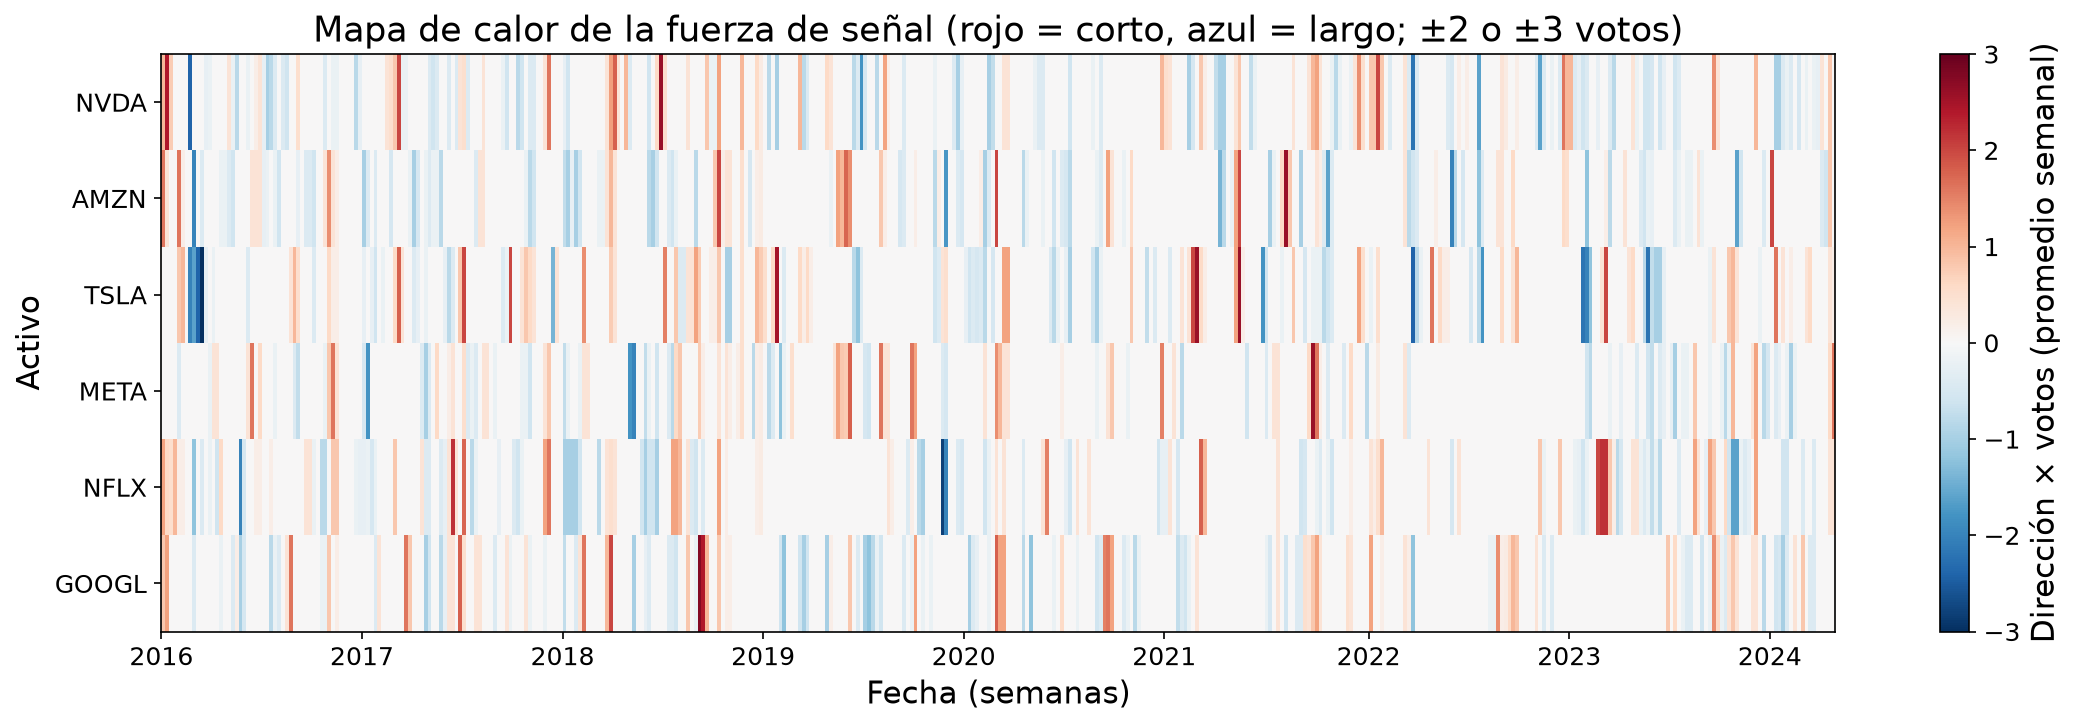

In [4]:
display(read("correlacion_senales.csv"))
show("14_correlacion_senales.png")
show("07b_fuerza_senal.png")

RSI y Bollinger están correlacionados positivamente pero debajo de 0.7; la EMA (tendencia) se opone a los osciladores (reversión), por eso los tres votos casi nunca coinciden (3 de 3 es raro).

## 3. Régimen

promedio_ventanas    0.468302
minimo               0.388129
maximo               0.546759
modelo_final         0.472711
objetivo             0.400000
dtype: float64

,proporcion_tiempo,n_episodios,duracion_promedio_observada,duracion_esperada_markov
Tendencia,0.402771,17.0,49.588235,52.625000
Reversión,0.332059,14.0,49.642857,49.642857
Crisis,0.265170,11.0,50.454545,50.454545


,features,n_features,silhouette
0,volatilidad+r2_tendencia,2,0.472711
1,atr_norm+r2_tendencia,2,0.456805
2,volatilidad+atr_norm+r2_tendencia,3,0.447931
3,volatilidad+fuerza_tendencia,2,0.416732
4,atr_norm+fuerza_tendencia,2,0.406538
5,volatilidad+fuerza_tendencia+r2_tendencia,3,0.399872
6,volatilidad+atr_norm+fuerza_tendencia,3,0.395654
7,volatilidad+atr_norm+fuerza_tendencia+r2_tende...,4,0.392780


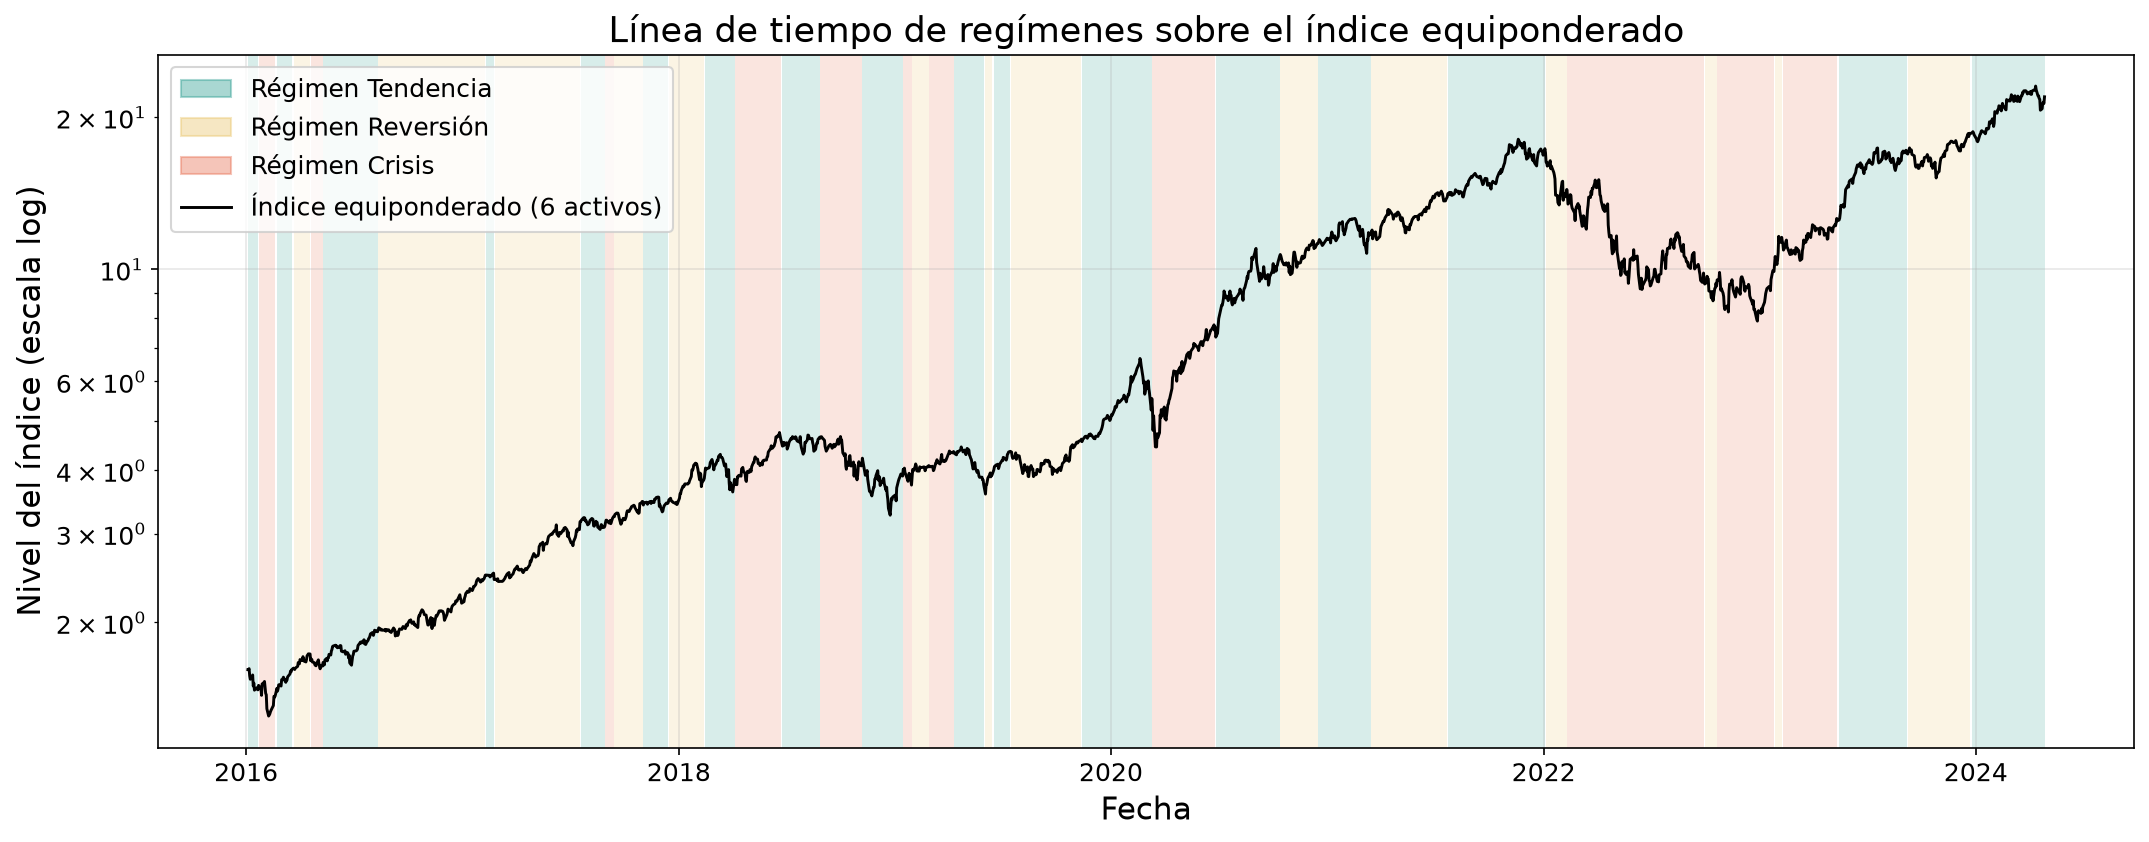

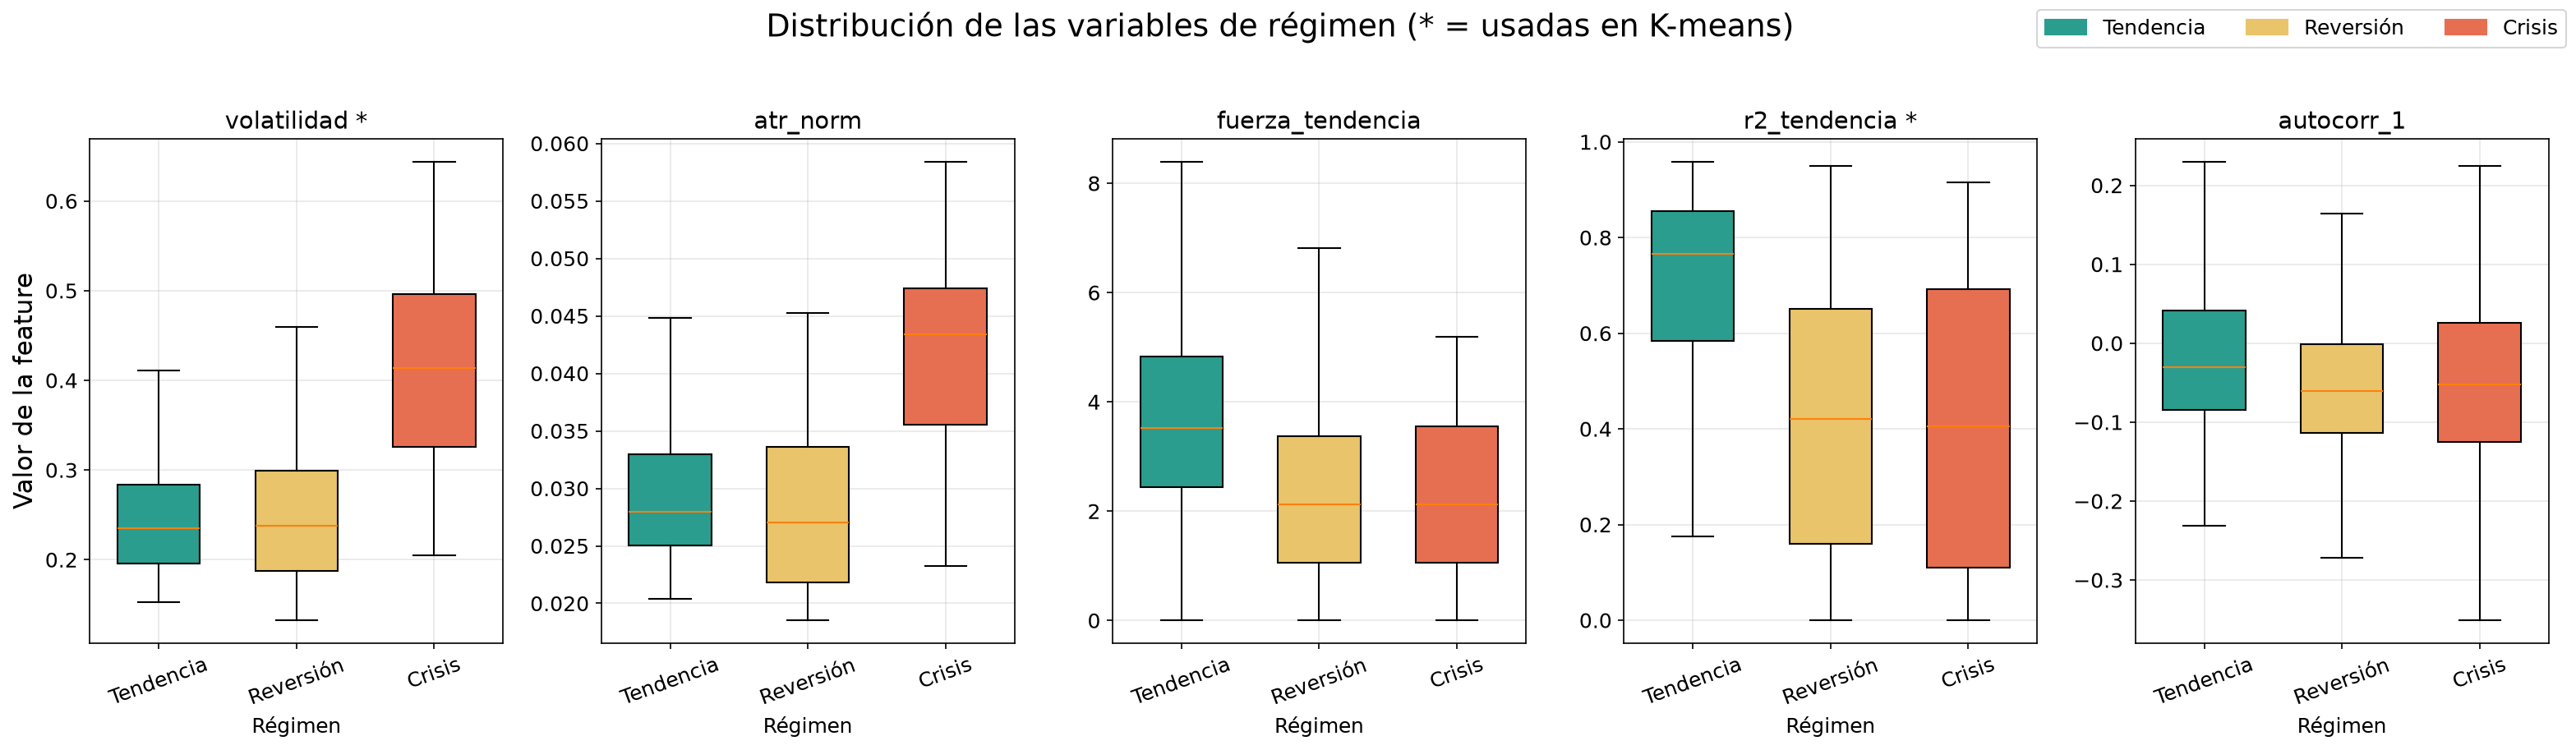

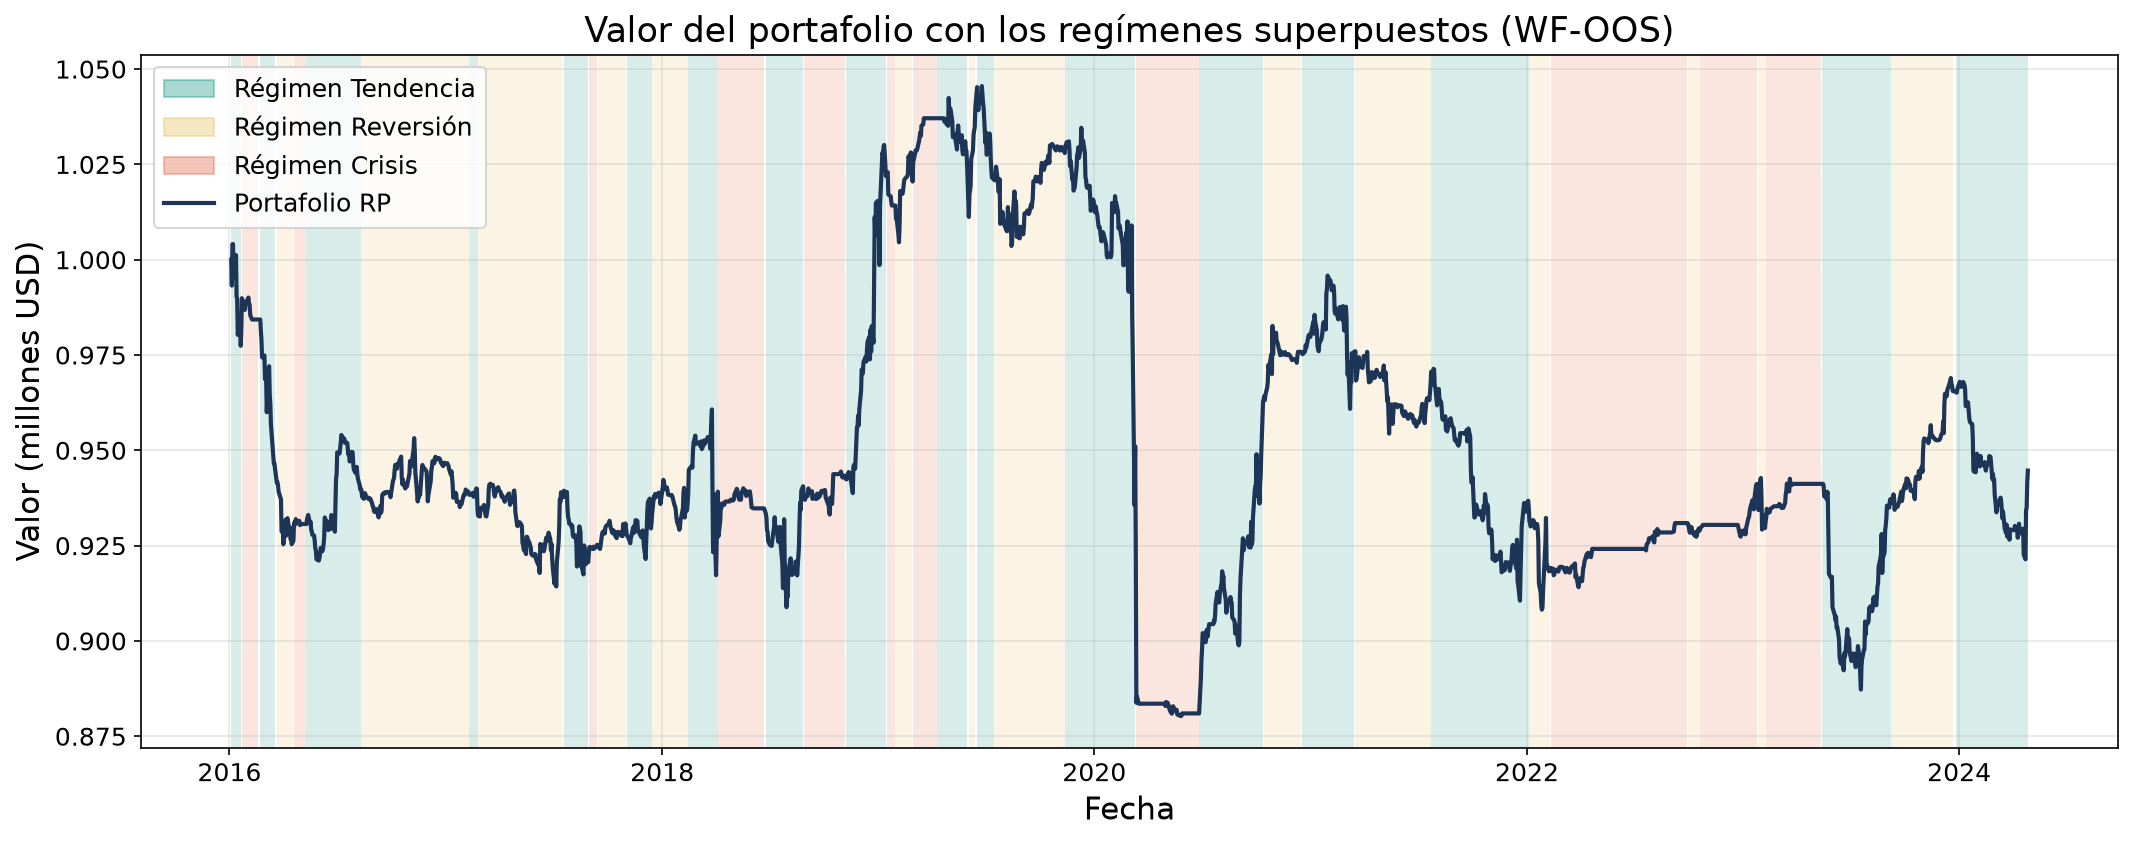

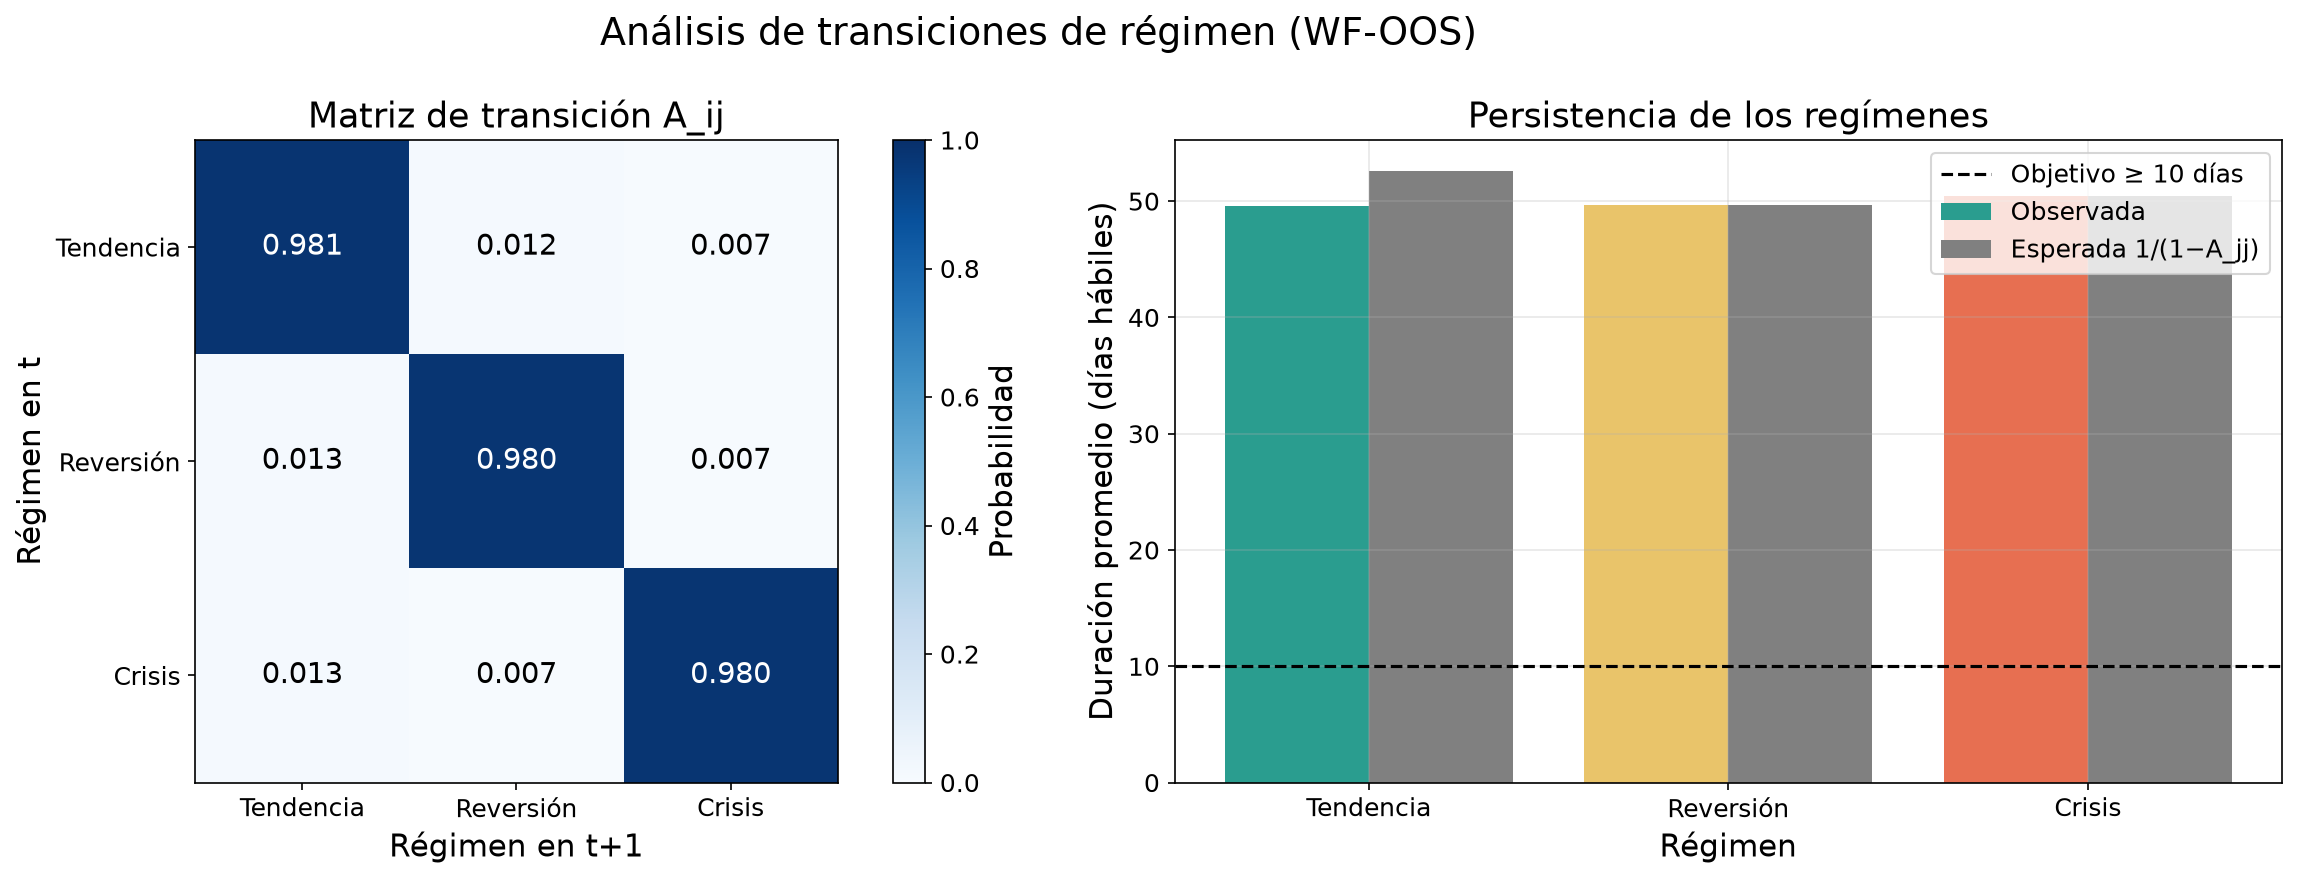

In [5]:
val = read_json("regimenes_validacion.json")
display(pd.Series(val["silhouette"]))
display(pd.DataFrame(val["persistencia_wf_oos"]["por_regimen"]).T)
display(read("regimenes_seleccion_features.csv").head(8))
for f in ["06a_regimenes_linea_tiempo.png", "06b_distribuciones_features.png", "06c_valor_con_regimenes.png", "09_transiciones_regimen.png"]:
    show(f)

## 4. Portafolio

,metodo,nombre,retorno_total,cagr,sharpe,mdd,calmar,pnl_neto,n_operaciones,turnover_anual,costos_totales,pnl_bruto
0,rp,Risk Parity (Spinu),-0.055324,-0.006832,-0.097364,0.158058,-0.043226,-55323.88073,624,5.273725,104402.2338,49078.353050
1,iv,RP naïve (1/σ),-0.029682,-0.003623,-0.039708,0.154147,-0.023503,-29681.52992,624,5.253636,105014.2992,75332.769330
2,ew,Pesos iguales,-0.102932,-0.012999,-0.207274,0.184629,-0.070408,-102932.05750,624,5.313428,103273.8060,341.748529


,estimador,cambio_medio_pesos,cambio_max_pesos,kappa_mediana,peso_medio_NVDA,peso_medio_AMZN,peso_medio_TSLA,peso_medio_META,peso_medio_NFLX,peso_medio_GOOGL
0,muestral,0.009335,0.066945,28.592636,0.132025,0.186692,0.133303,0.175207,0.156073,0.216700
1,ewma,0.037553,0.196247,37.579890,0.132179,0.186924,0.132091,0.174388,0.157626,0.216792
2,ledoit_wolf,0.008411,0.058568,13.641181,0.135768,0.185385,0.136425,0.174098,0.158291,0.210033


,sistema,activo,rc_promedio_abs,peso_promedio_abs
0,RP,NVDA,0.183357,0.023904
1,RP,AMZN,0.140610,0.031841
2,RP,TSLA,0.190645,0.023477
3,RP,META,0.136232,0.030236
4,RP,NFLX,0.175986,0.027662
5,RP,GOOGL,0.194852,0.037706
6,RP,concentracion_max_rc,0.678123,NaN
7,RP,herfindahl_rc,0.625854,NaN
8,EW,NVDA,0.216813,0.030539
9,EW,AMZN,0.125751,0.028024


rebalanceos                                 {'crisis': 11, 'calendario + banda': 6}
rebalanceos_omitidos_por_banda                                                  204
turnover_por_rebalanceo                                                    0.101355
rebalanceos_por_anio                                                       2.046823
costo_anual_rebalanceo                                                     0.000519
conflictos                                                                       26
conflictos_empatados                                                              5
kappa_mediana                                                             34.506728
kappa_max                                                                365.244023
max_exposicion_post_ejecucion                                              0.667917
max_exposicion_al_cierre                                                   0.670681
exposicion_promedio                                                         

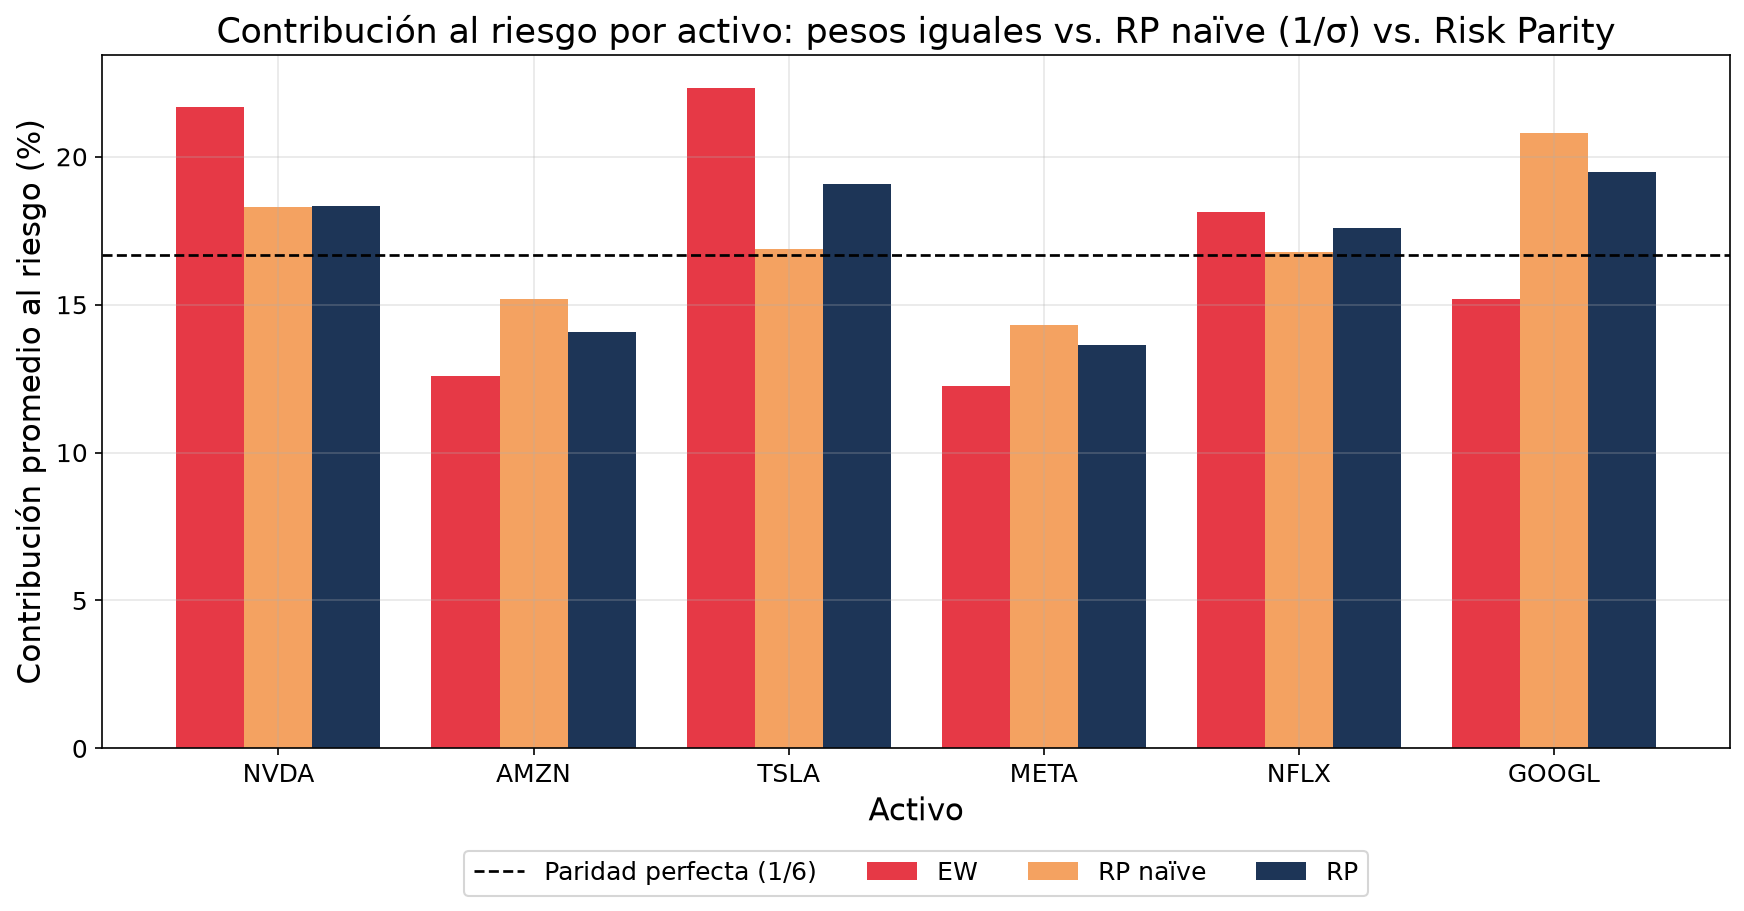

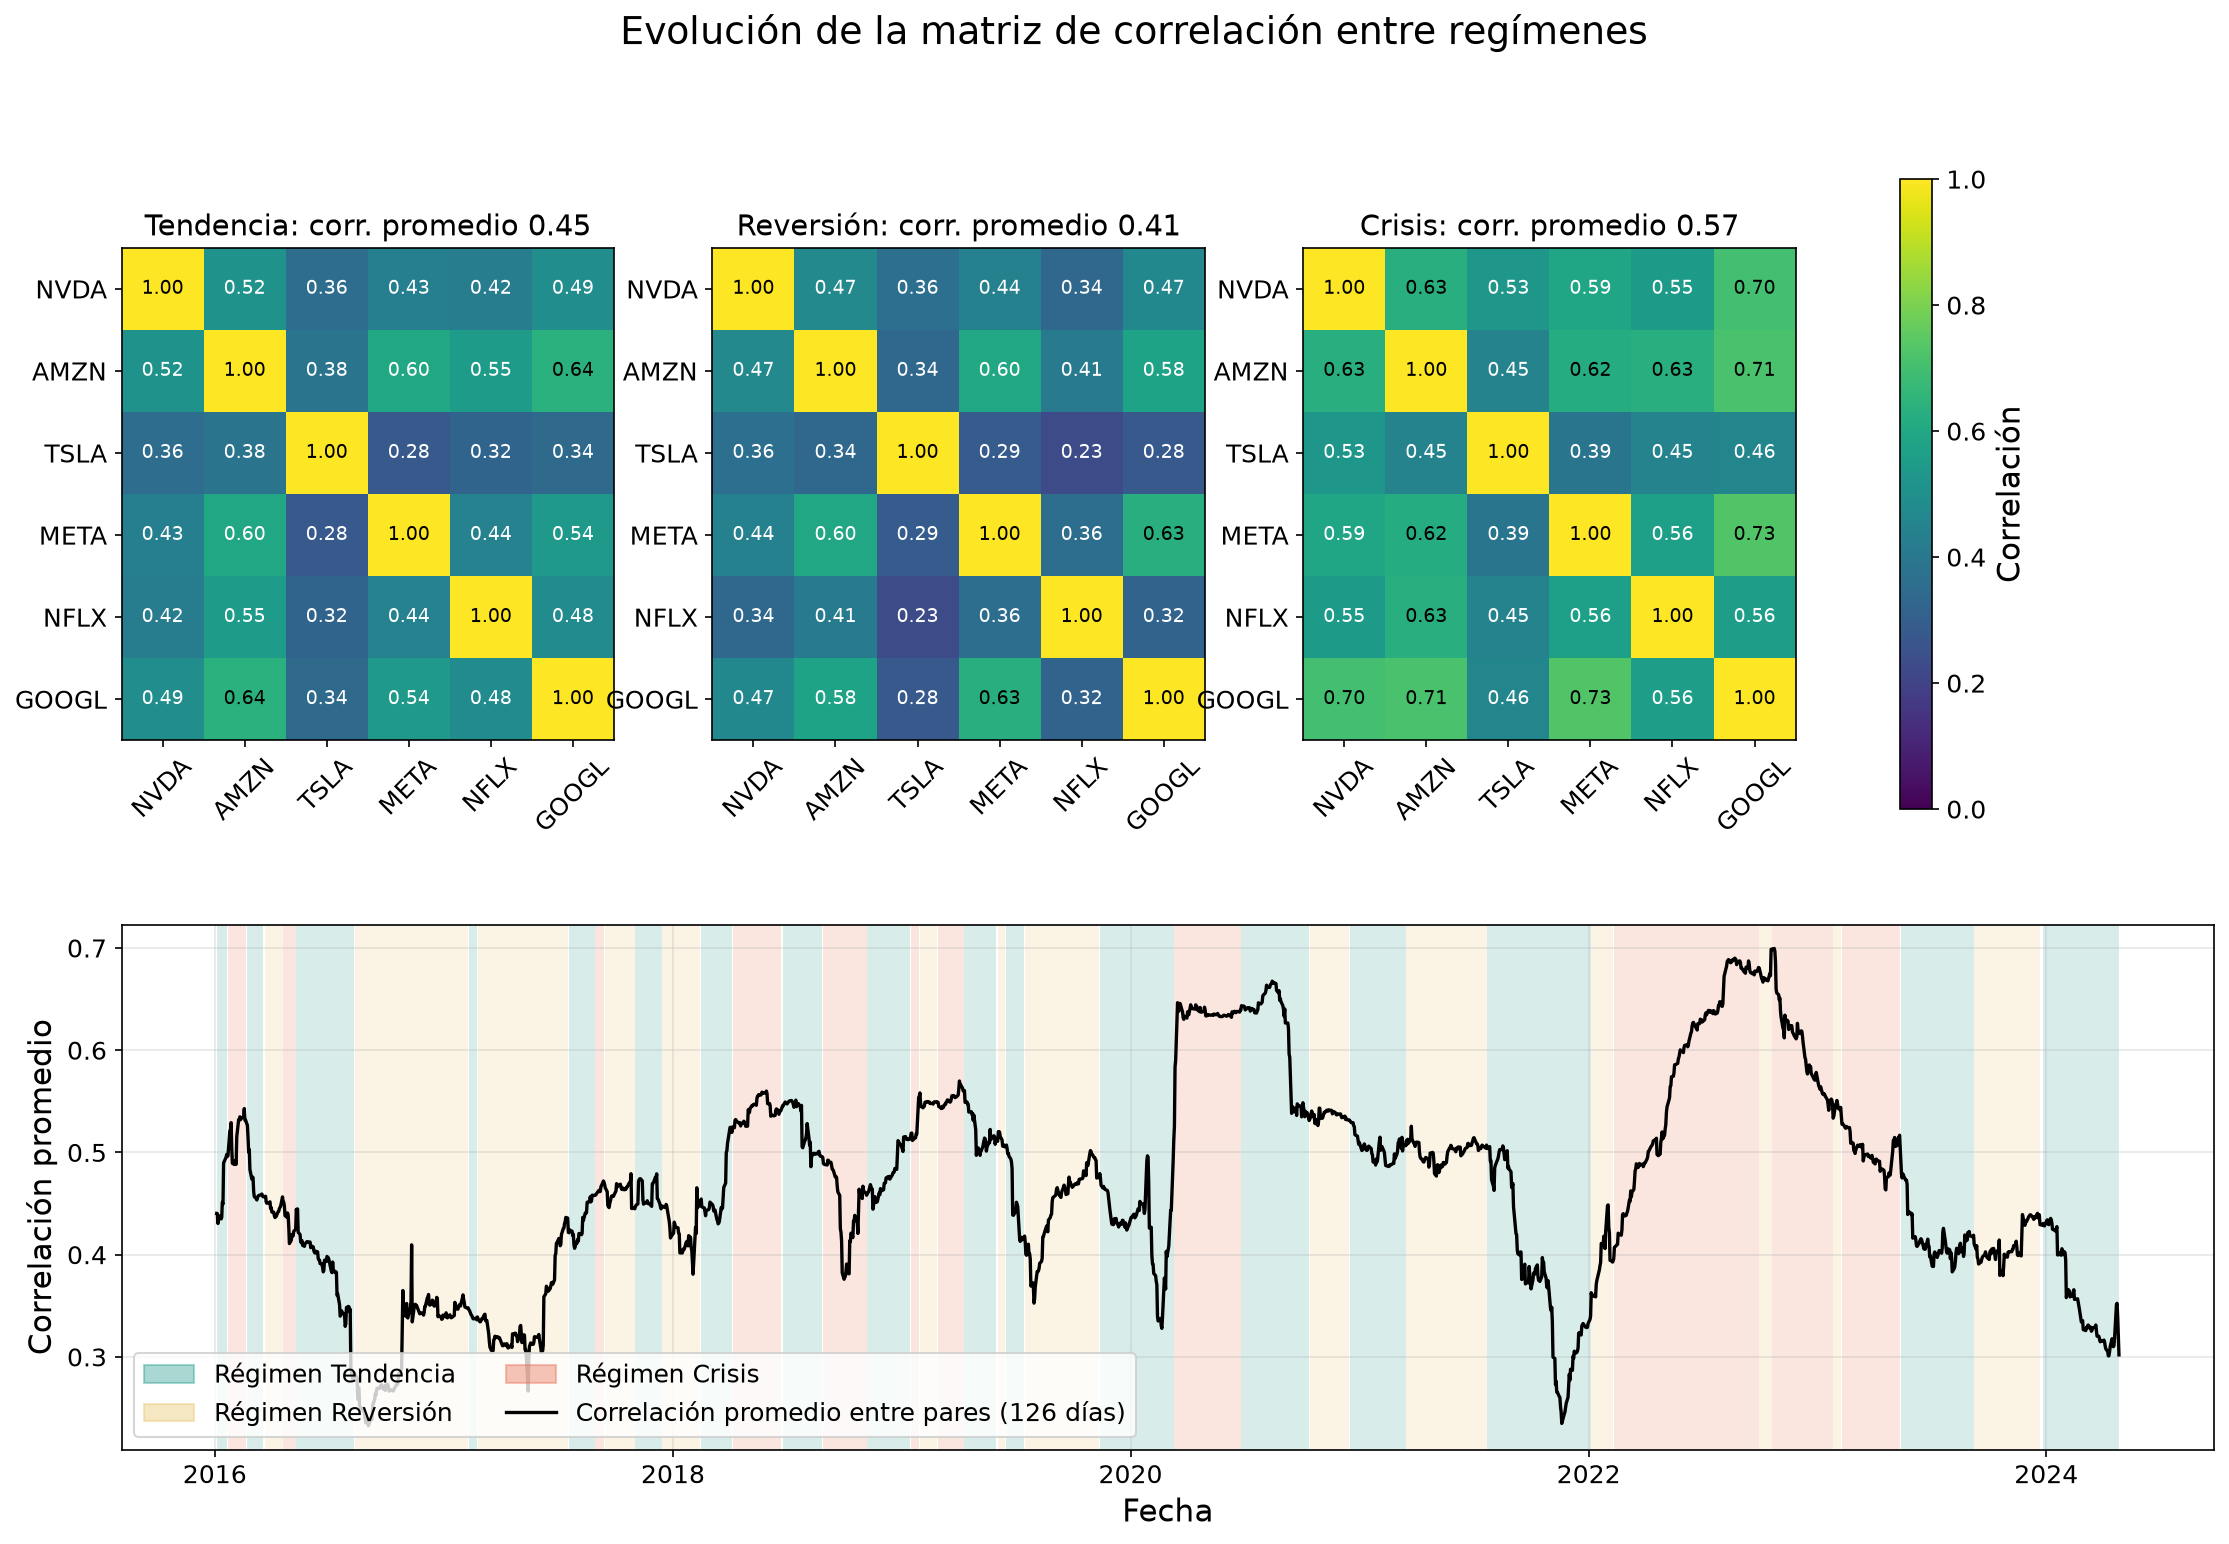

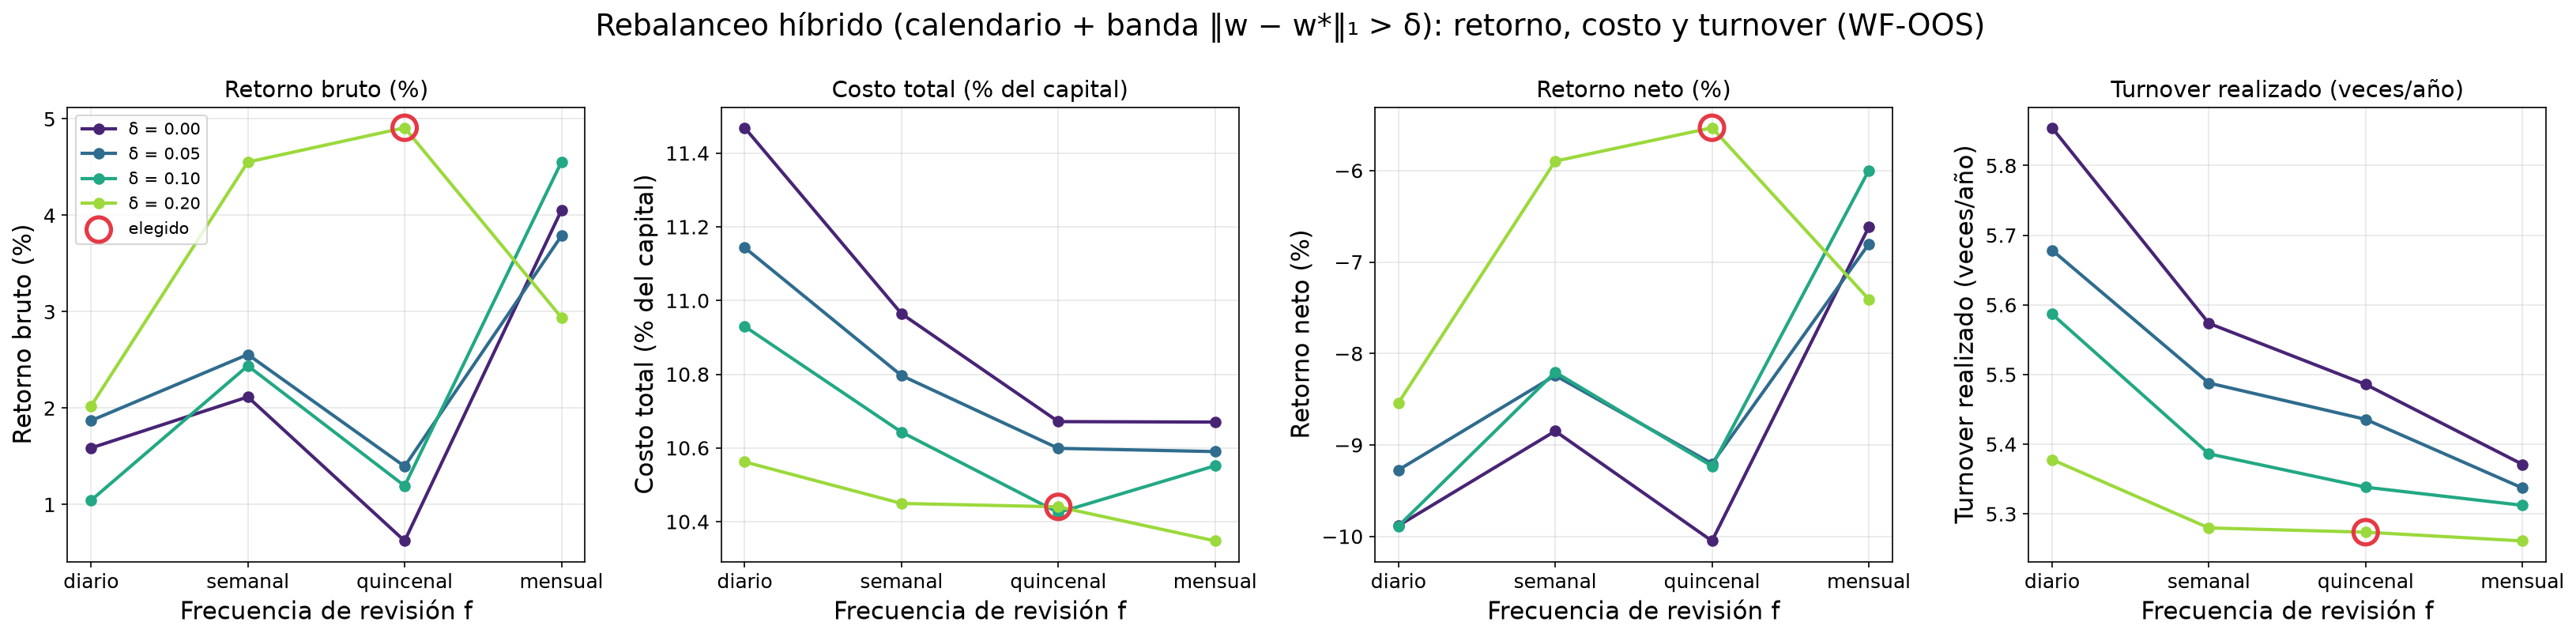

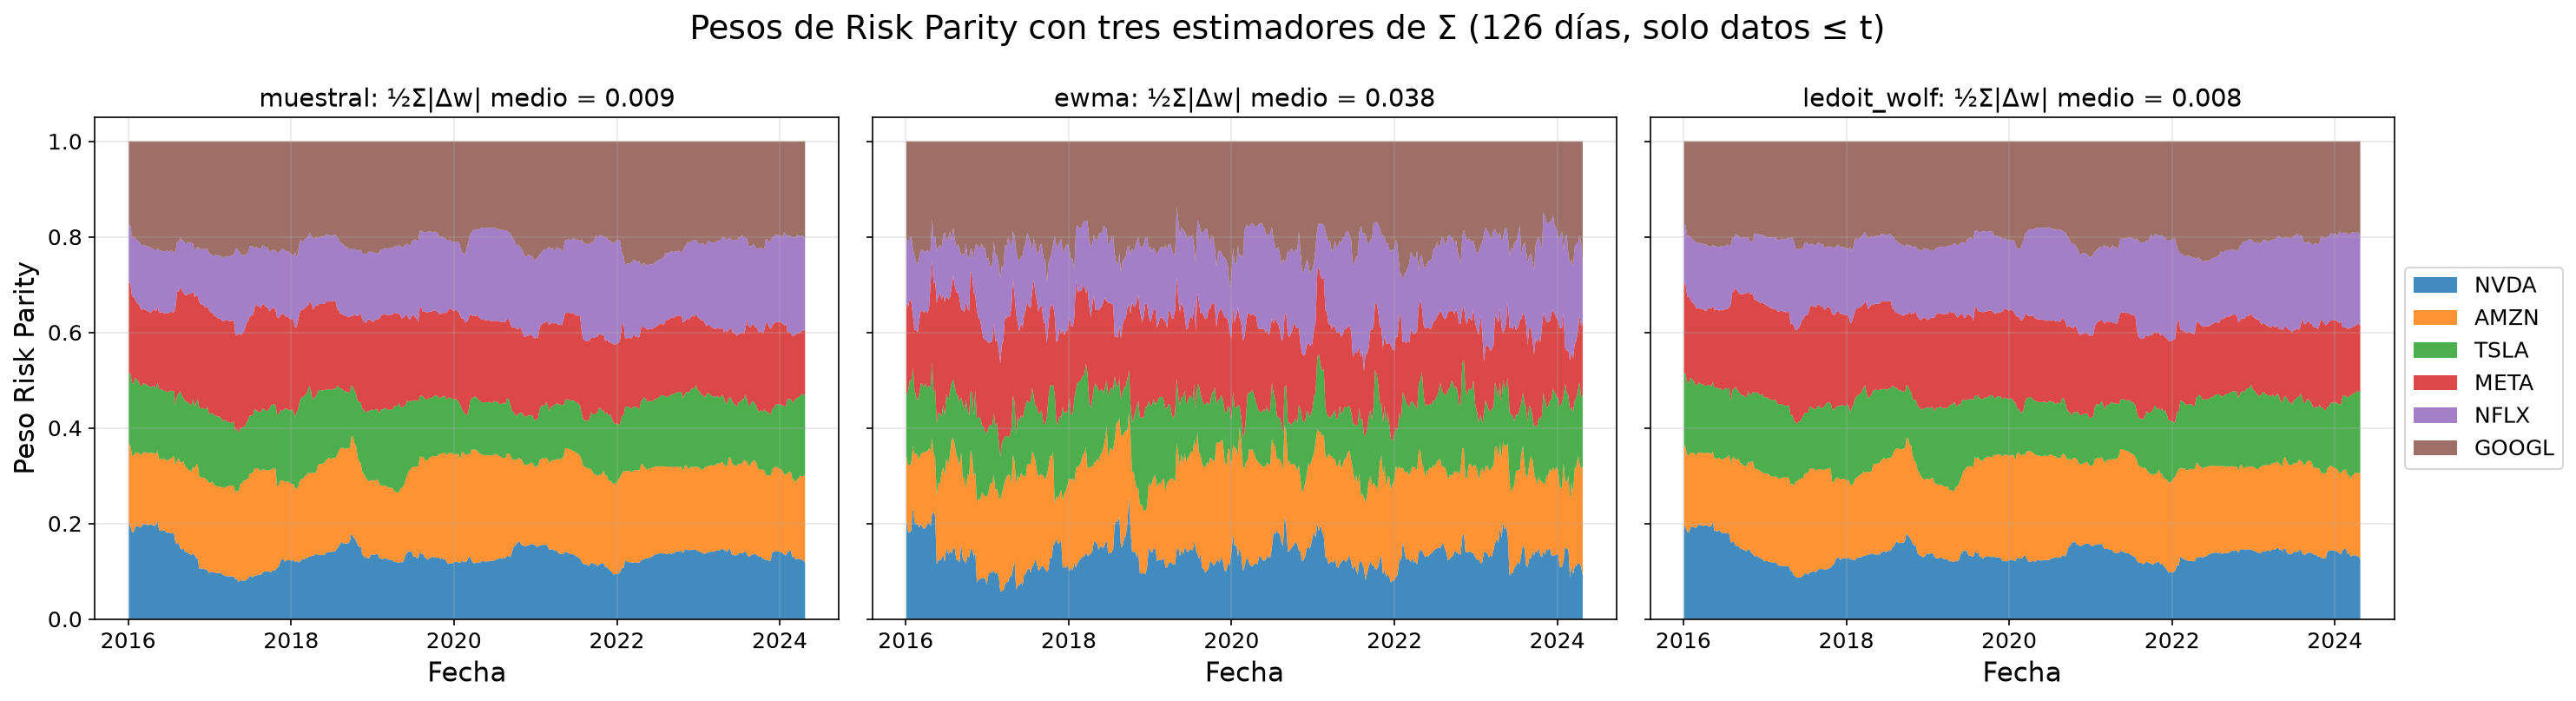

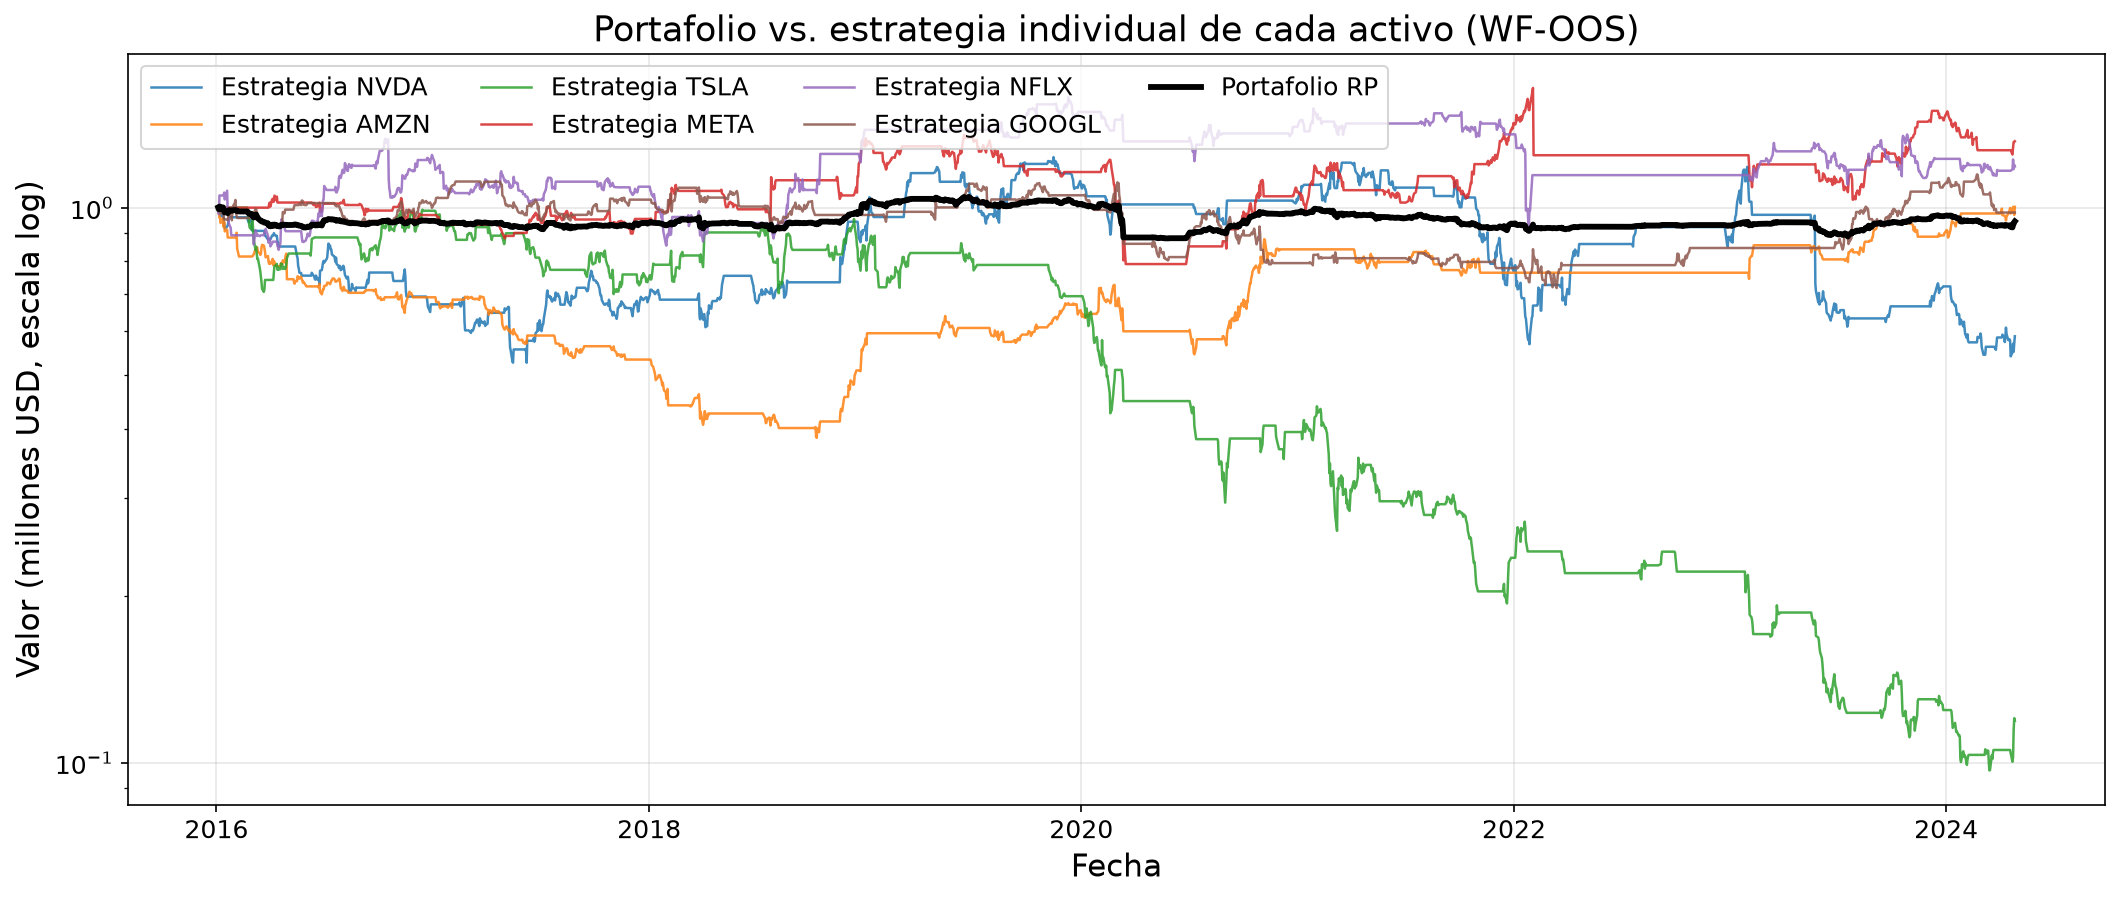

In [6]:
display(read("ponderaciones_comparacion.csv"))
display(read("covarianza_estimadores.csv"))
display(read("rp_vs_ew_contribuciones.csv"))
display(pd.Series(read_json("portafolio_resumen.json")["RP"]))
for f in ["07a_contribuciones_riesgo.png", "07c_correlacion_por_regimen.png", "07d_barrido_rebalanceo.png", "15_estimadores_covarianza.png", "10_portafolio_vs_activos.png"]:
    show(f)

## 5. Optimización y walk-forward

,variante,cagr_oos,cagr_is_promedio,wfe_cagr,calmar_oos,calmar_is_promedio,wfe_calmar,mdd_oos,n_operaciones,elegida
0,por_activo,-0.006832,0.104511,-0.065373,-0.043226,6.264846,-0.006900,0.158058,624,True
1,compartido,-0.015811,0.034653,-0.456277,-0.092947,1.825347,-0.050920,0.170113,666,False
2,anclado_por_activo,-0.031783,0.103241,-0.307849,-0.118131,2.525881,-0.046768,0.269047,320,False


,conjunto,inicio,fin,dias,retorno_total,cagr,volatilidad,sharpe,sortino,mdd,...,win_rate,payoff,profit_factor,turnover_anual,costos_totales,pnl_bruto,pnl_neto,costos_vs_pnl_bruto,n_ventanas,sistema
0,WF-IS,2015-07-01,2024-03-28,125.81,0.049454,0.104511,0.053733,1.831737,3.767252,0.030437,...,0.552966,1.488384,2.103554,6.042192,7750.331221,5.720393e+04,4.945360e+04,0.262220,100.0,RP
1,WF-IS,2015-07-01,2024-03-28,125.81,0.054516,0.115803,0.057241,1.851615,3.897028,0.032227,...,0.553033,1.504026,2.129871,6.106877,7848.463706,6.236401e+04,5.451555e+04,0.162608,100.0,EW
2,WF-IS,2015-07-01,2024-03-28,125.81,0.196959,0.508534,0.302708,1.426429,2.221935,0.184701,...,0.710000,7.323573,18.541971,2.004630,2746.511398,1.997060e+05,1.969595e+05,0.017348,100.0,Buy & Hold
3,WF-OOS,2016-01-04,2024-04-26,2093.00,-0.055324,-0.006832,0.054881,-0.097364,-0.128058,0.158058,...,0.421474,1.292729,0.941795,5.273725,104402.233800,4.907835e+04,-5.532388e+04,2.127256,NaN,RP
4,WF-OOS,2016-01-04,2024-04-26,2093.00,-0.102932,-0.012999,0.055640,-0.207274,-0.275741,0.184629,...,0.419872,1.250275,0.904896,5.313428,103273.806000,3.417485e+02,-1.029321e+05,302.192393,NaN,EW
5,WF-OOS,2016-01-04,2024-04-26,2093.00,-0.029682,-0.003623,0.054218,-0.039708,-0.051991,0.154147,...,0.421474,1.325709,0.965821,5.253636,105014.299200,7.533277e+04,-2.968153e+04,1.394006,NaN,RP naïve
6,WF-OOS,2016-01-04,2024-04-26,2093.00,22.209344,0.460516,0.369546,1.210702,1.772132,0.608699,...,1.000000,NaN,NaN,0.121147,30296.429080,2.223964e+07,2.220934e+07,0.001362,NaN,Buy & Hold


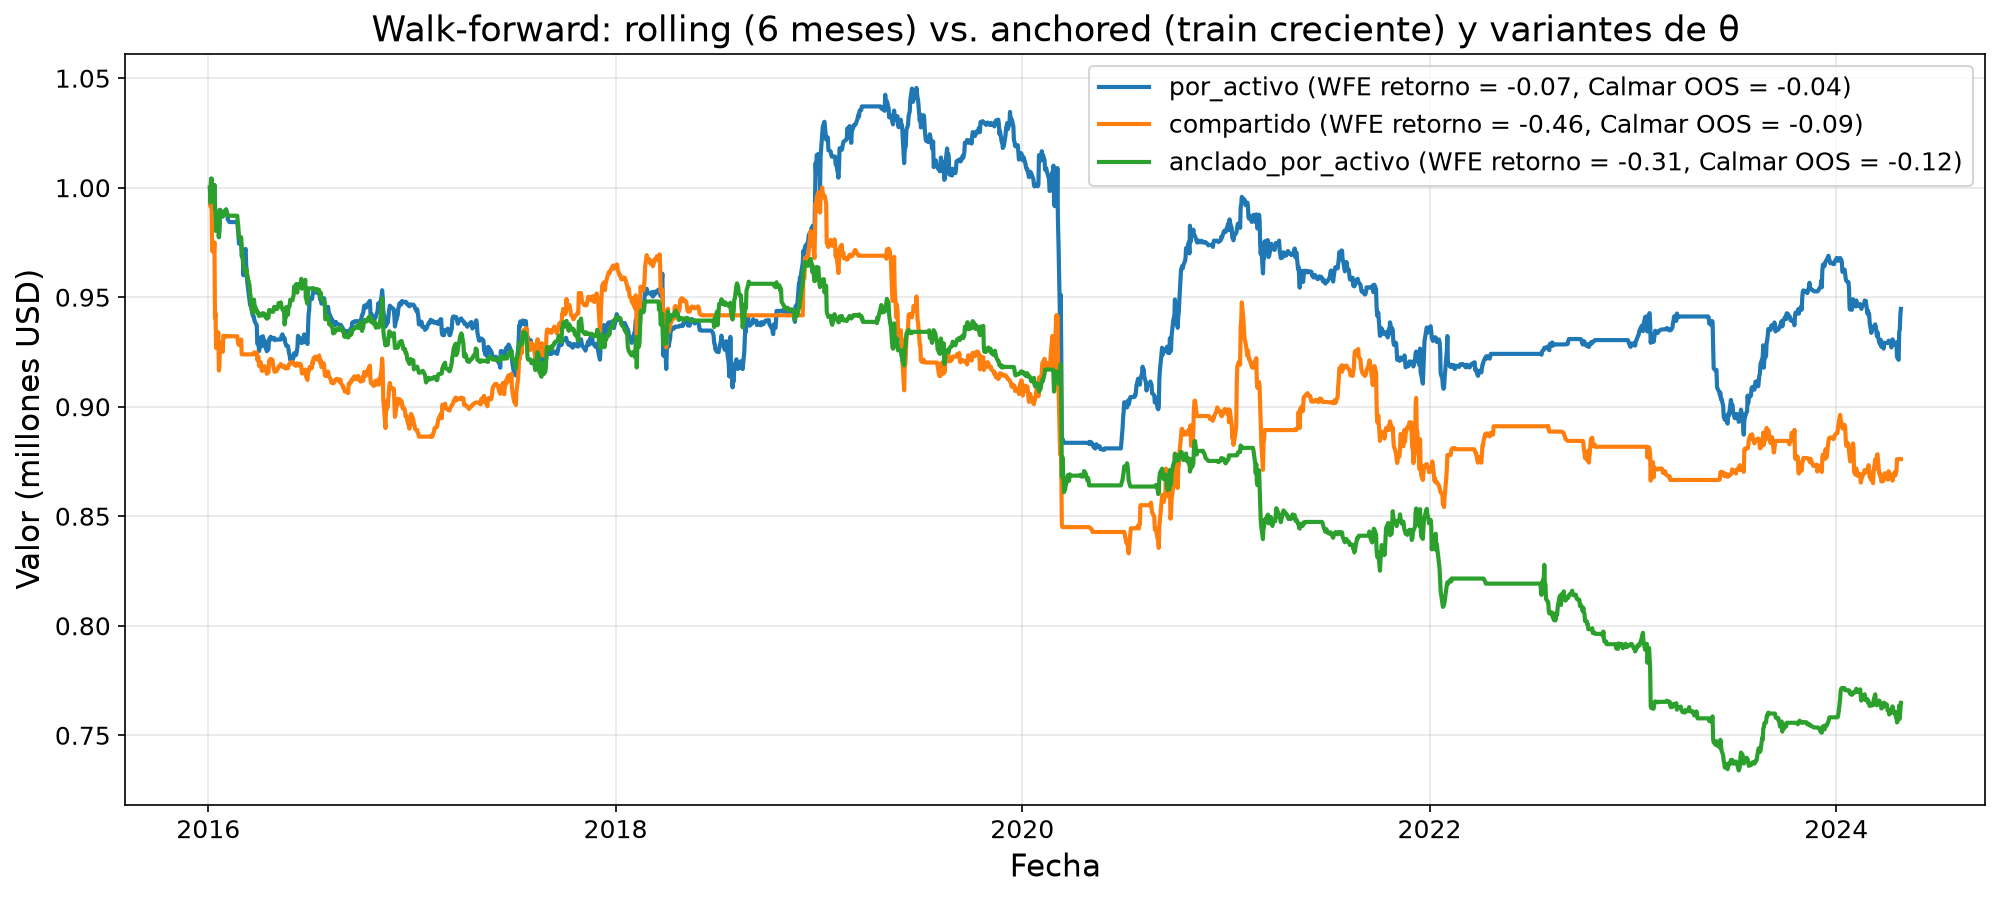

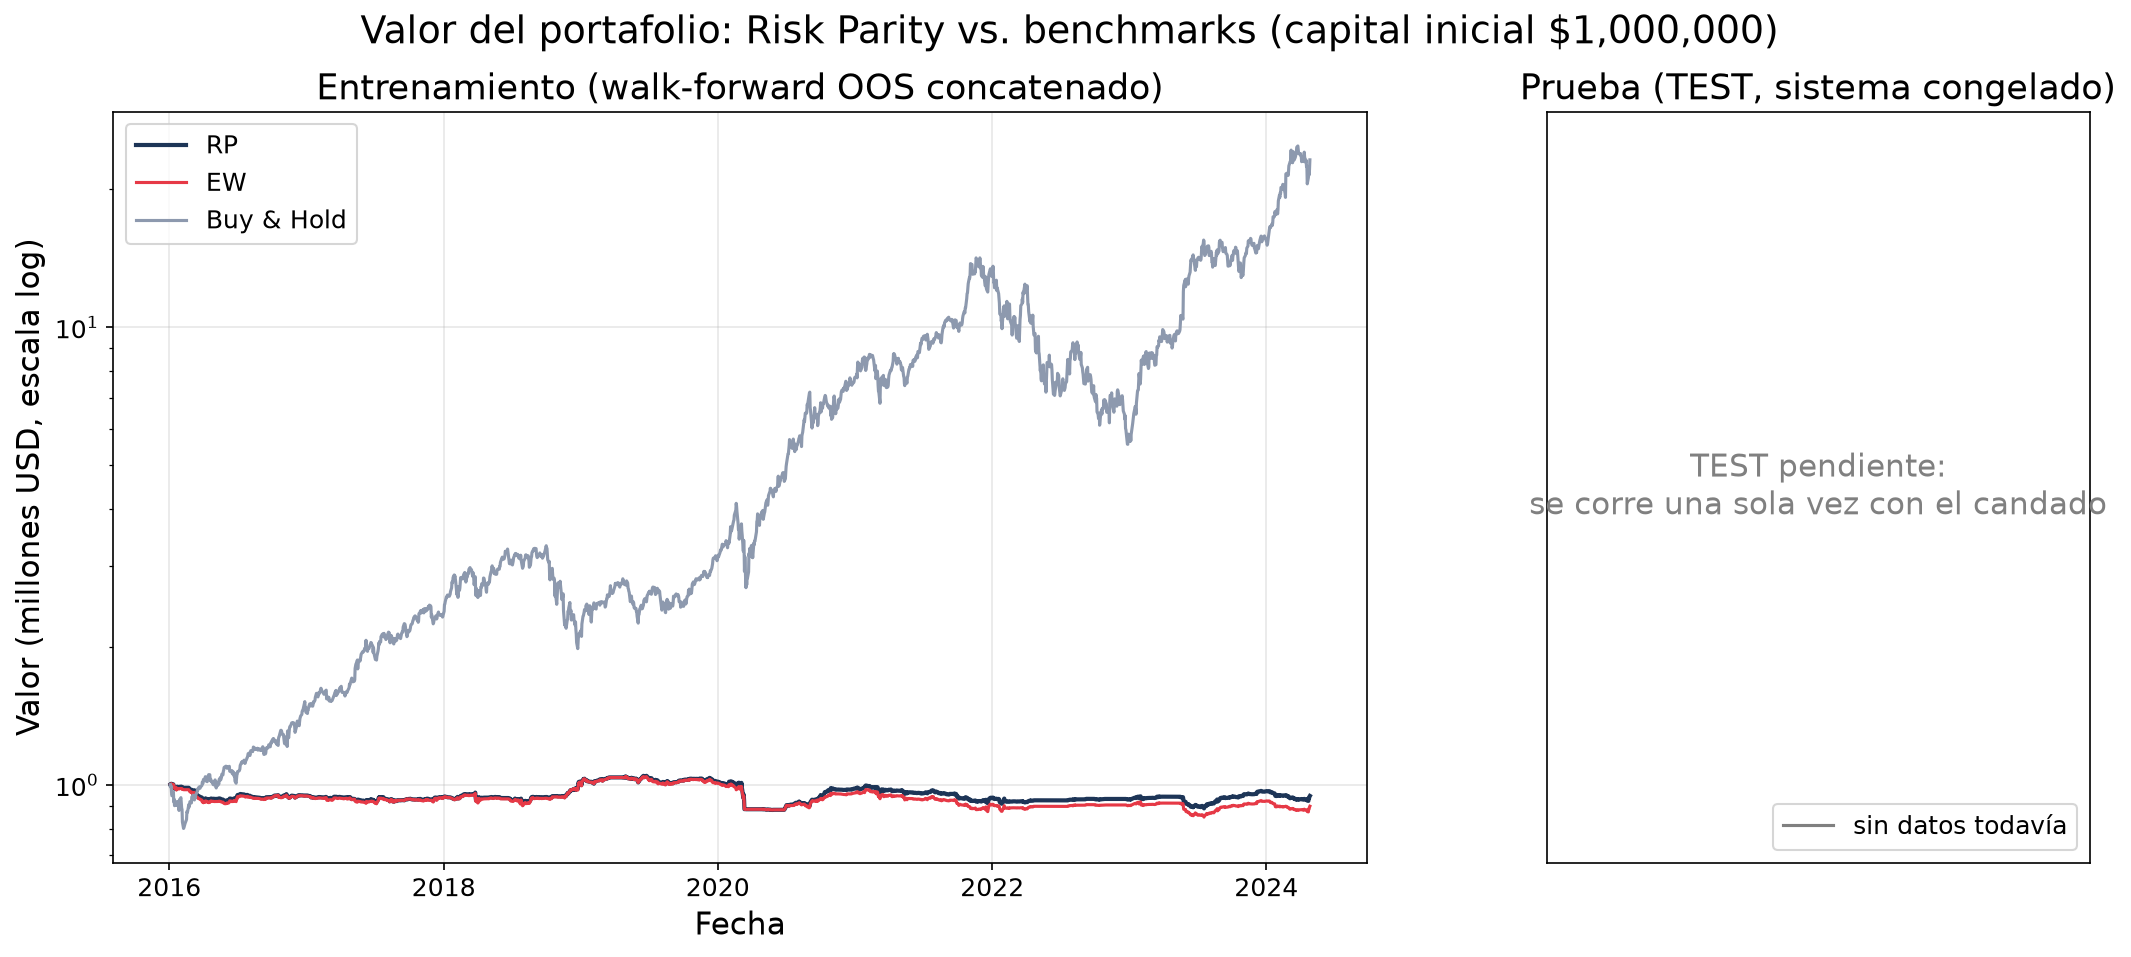

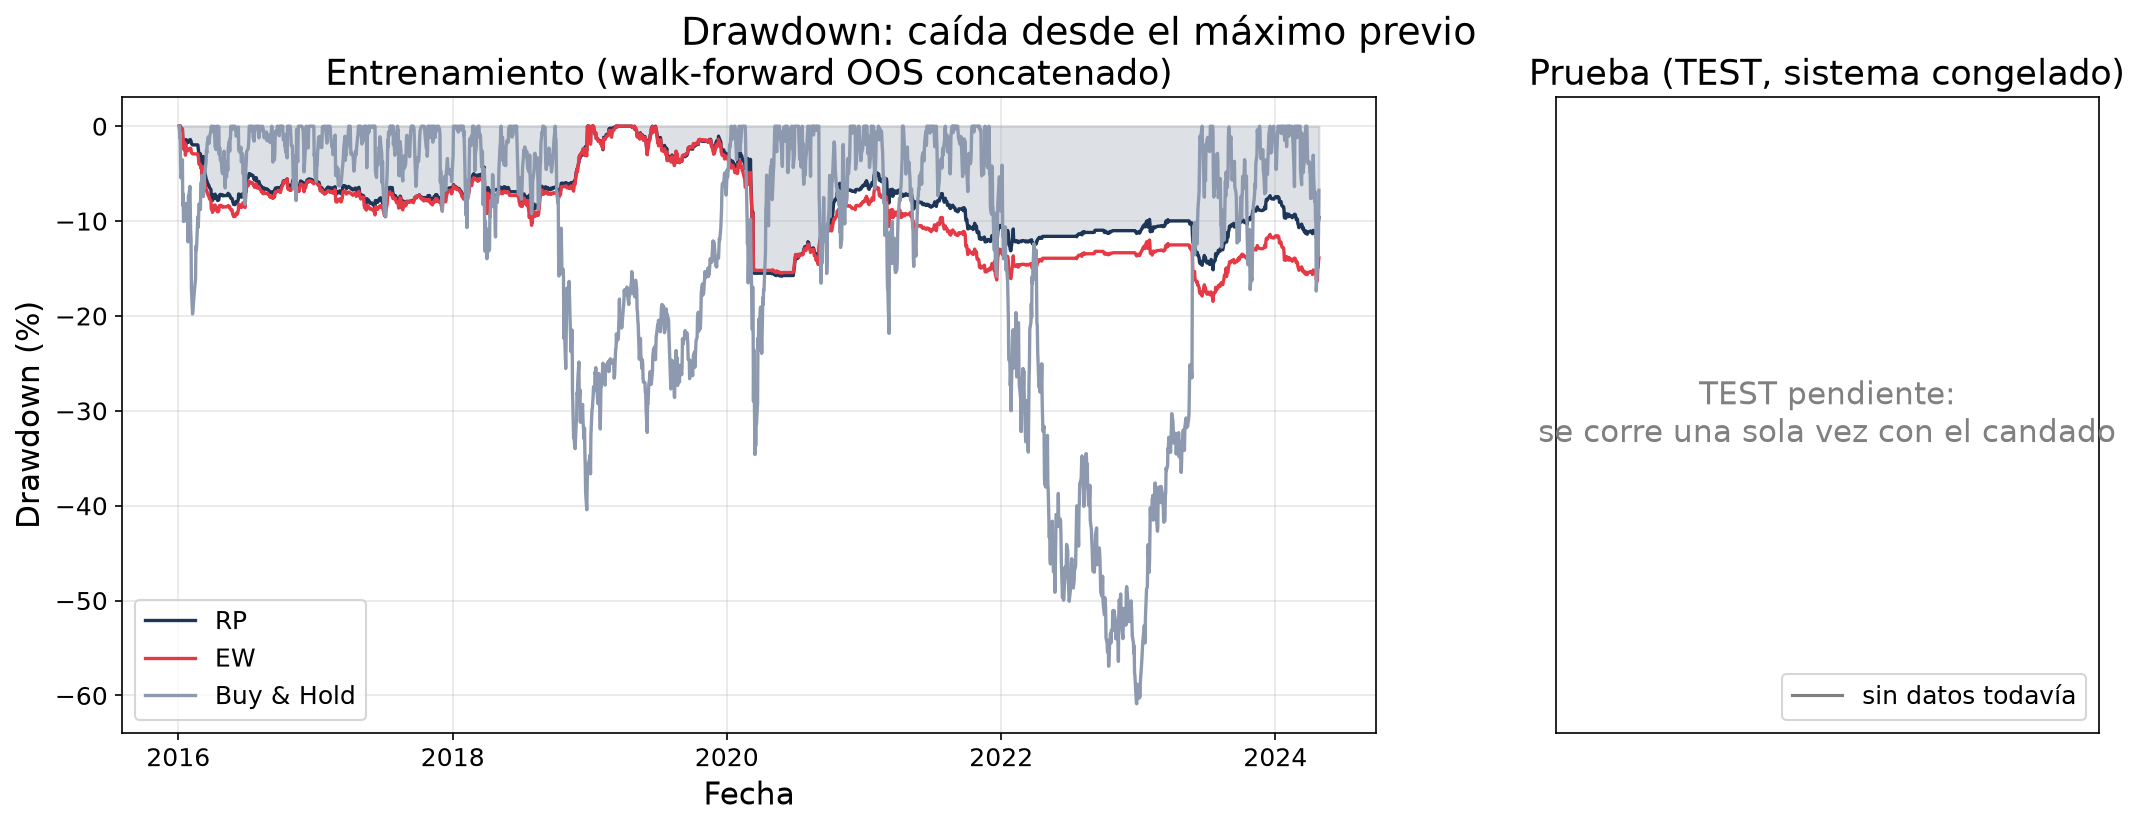

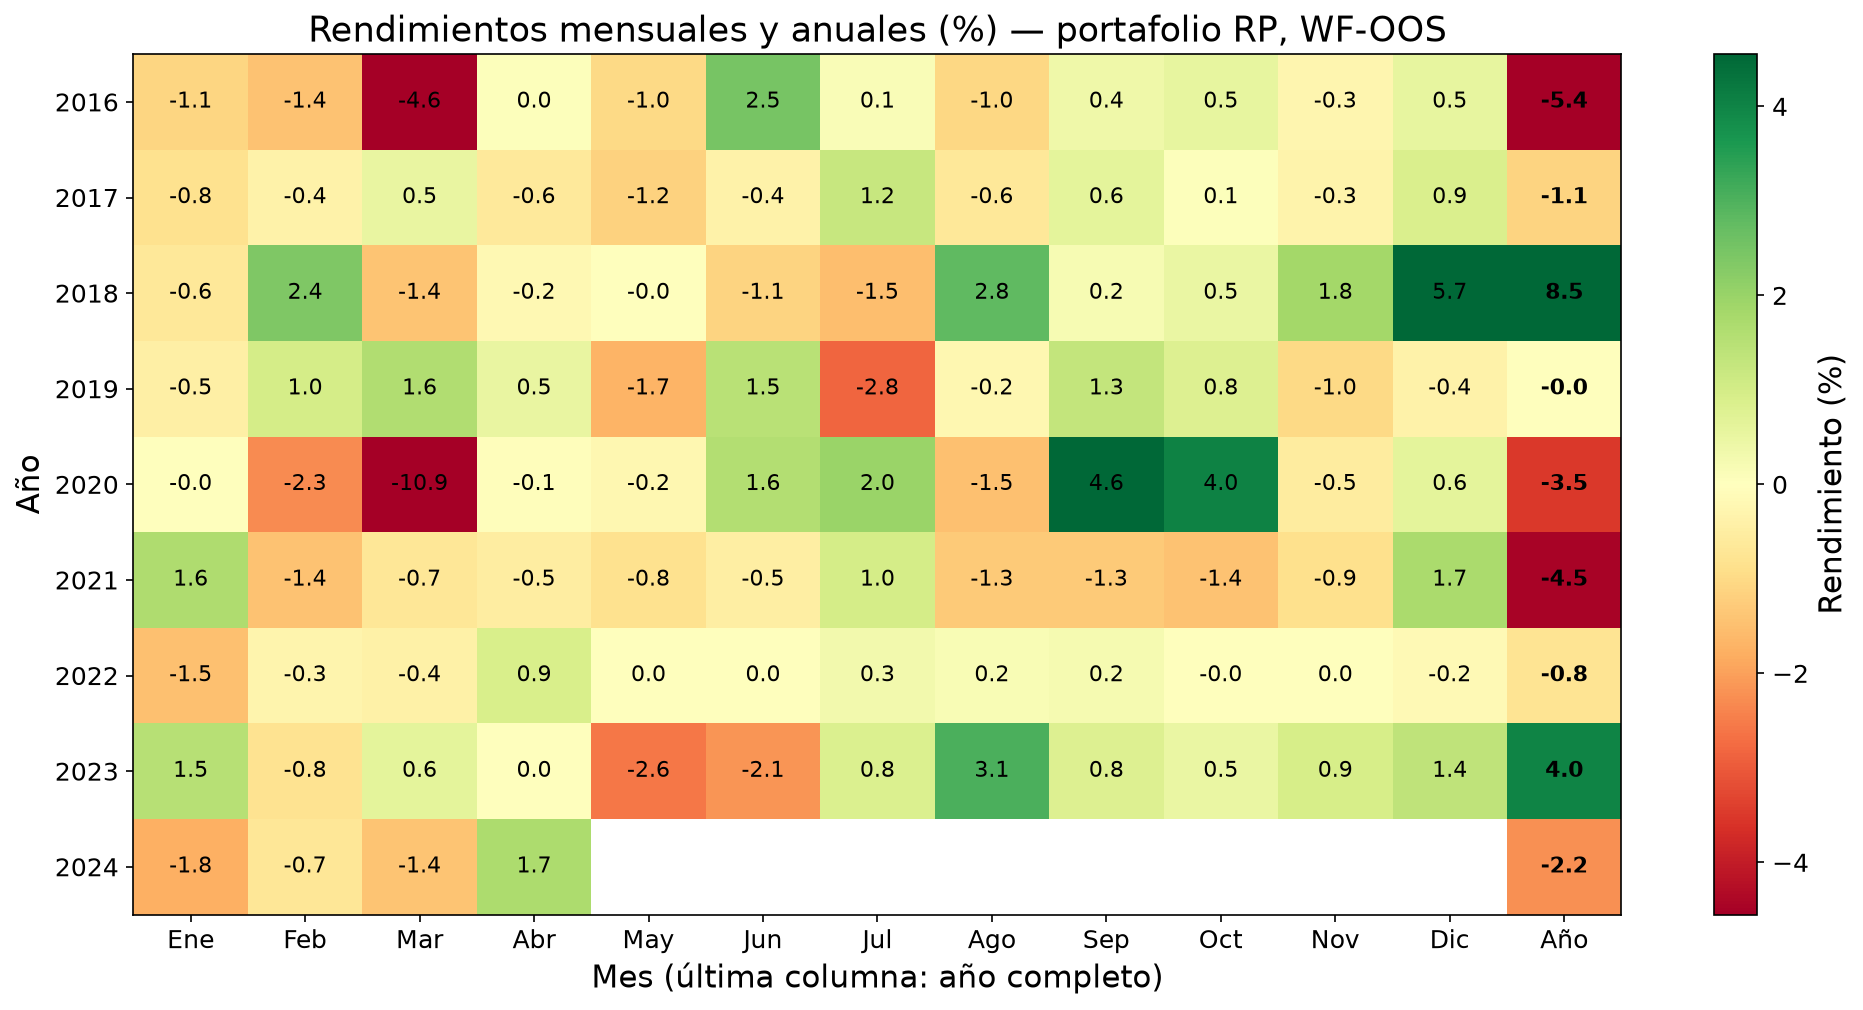

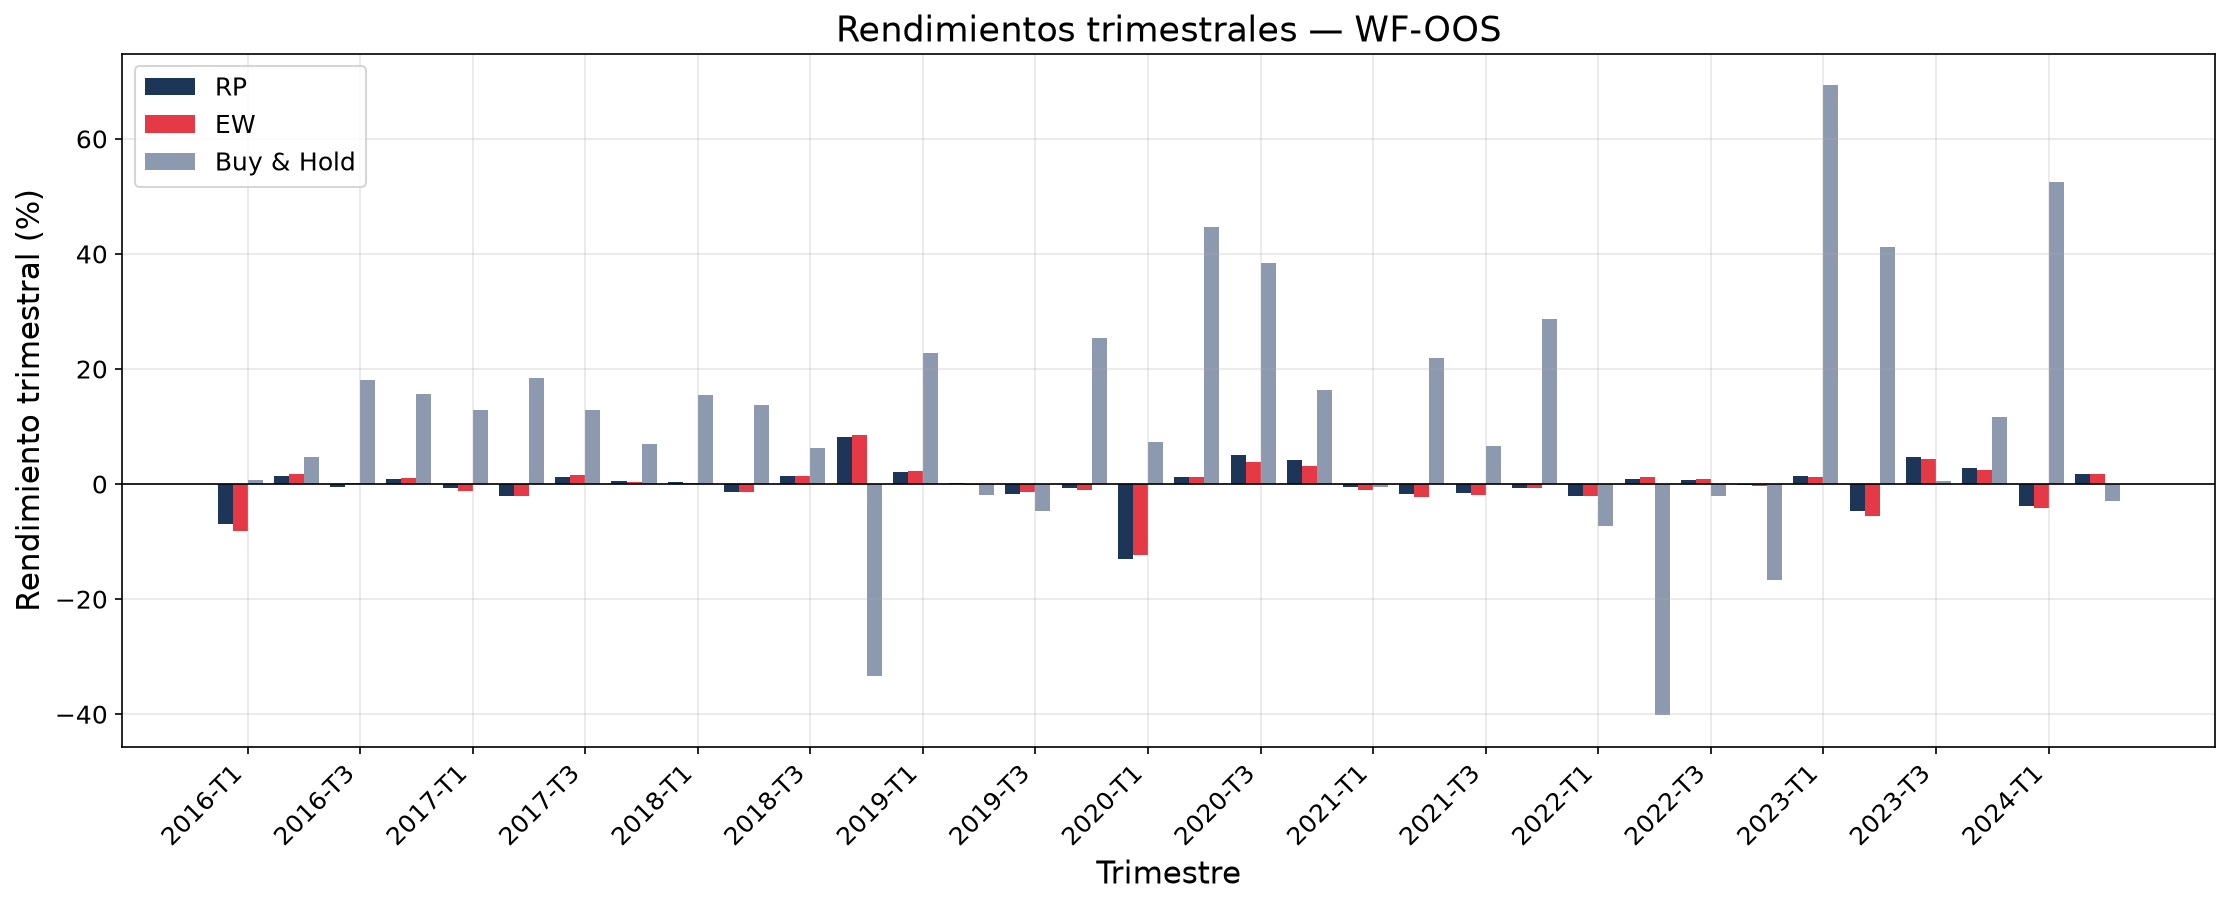

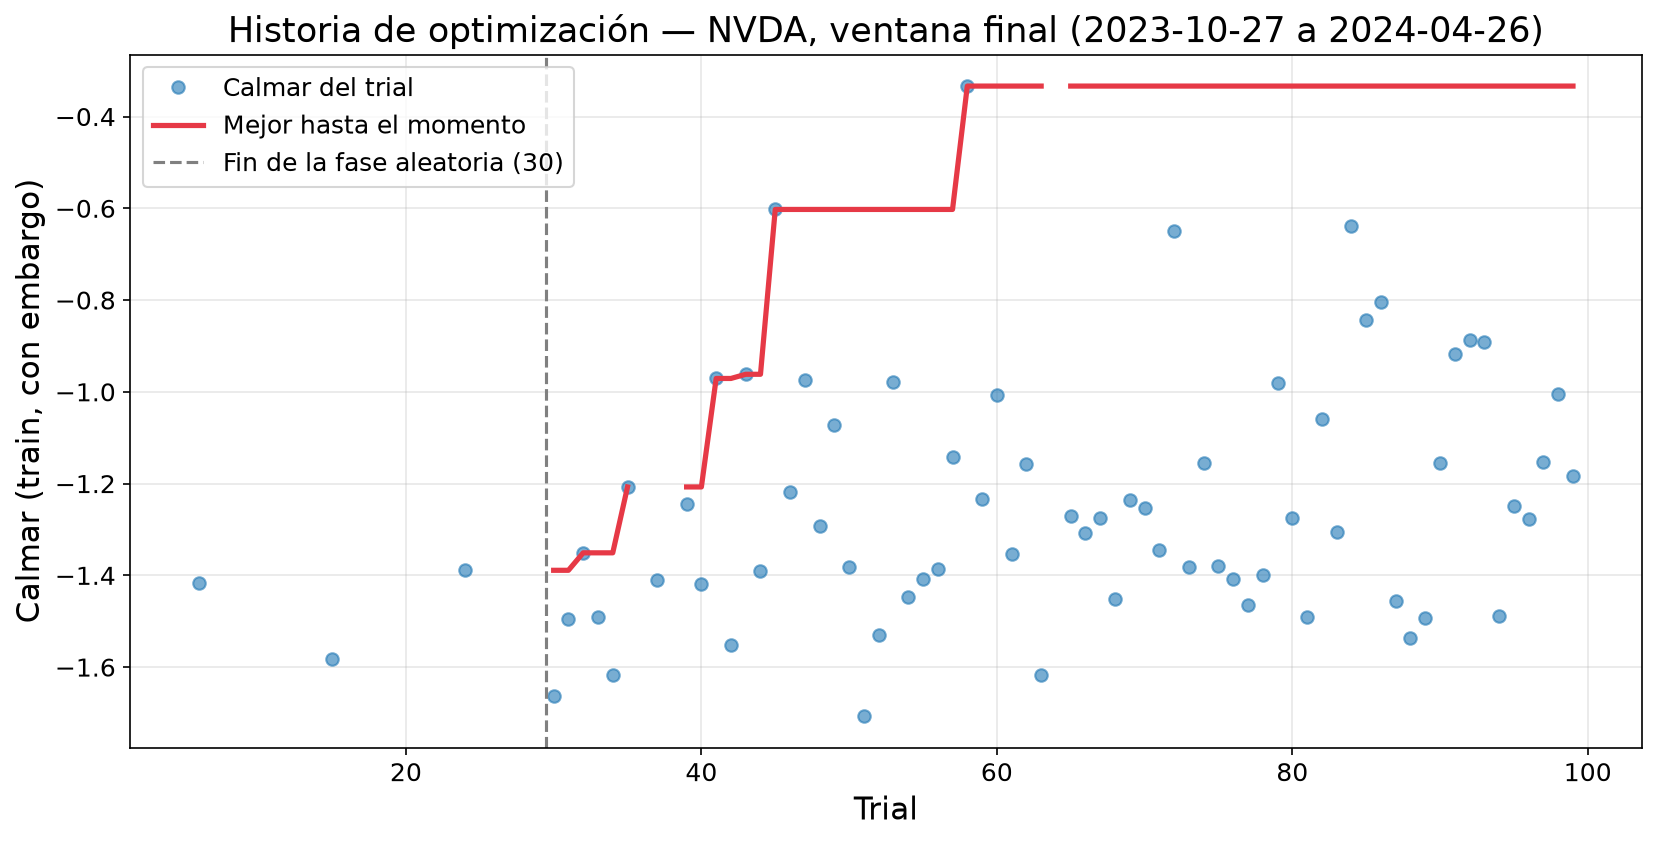

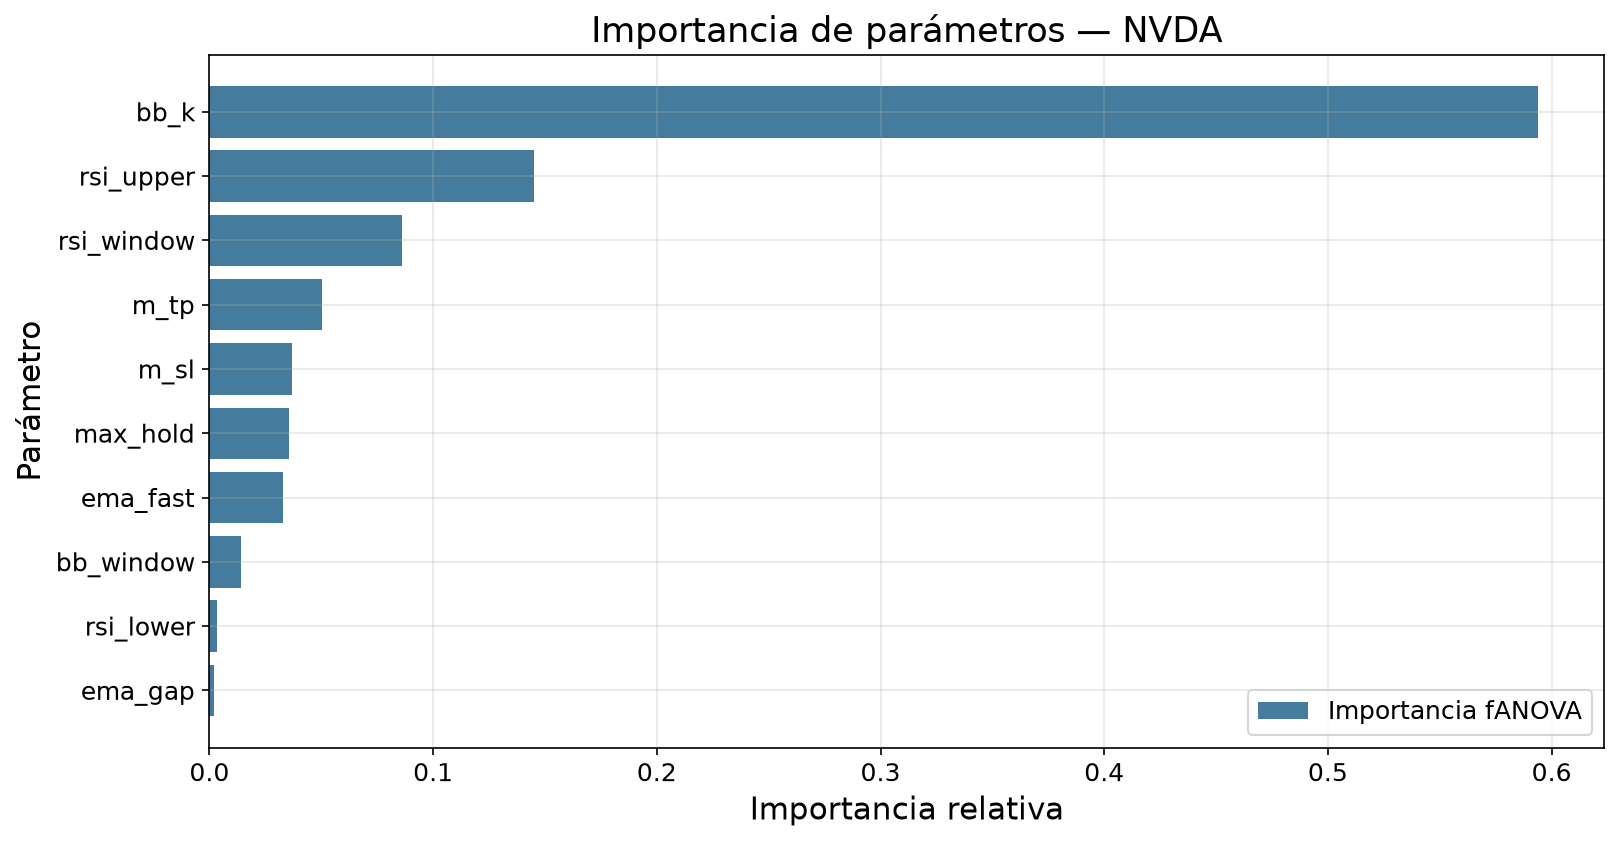

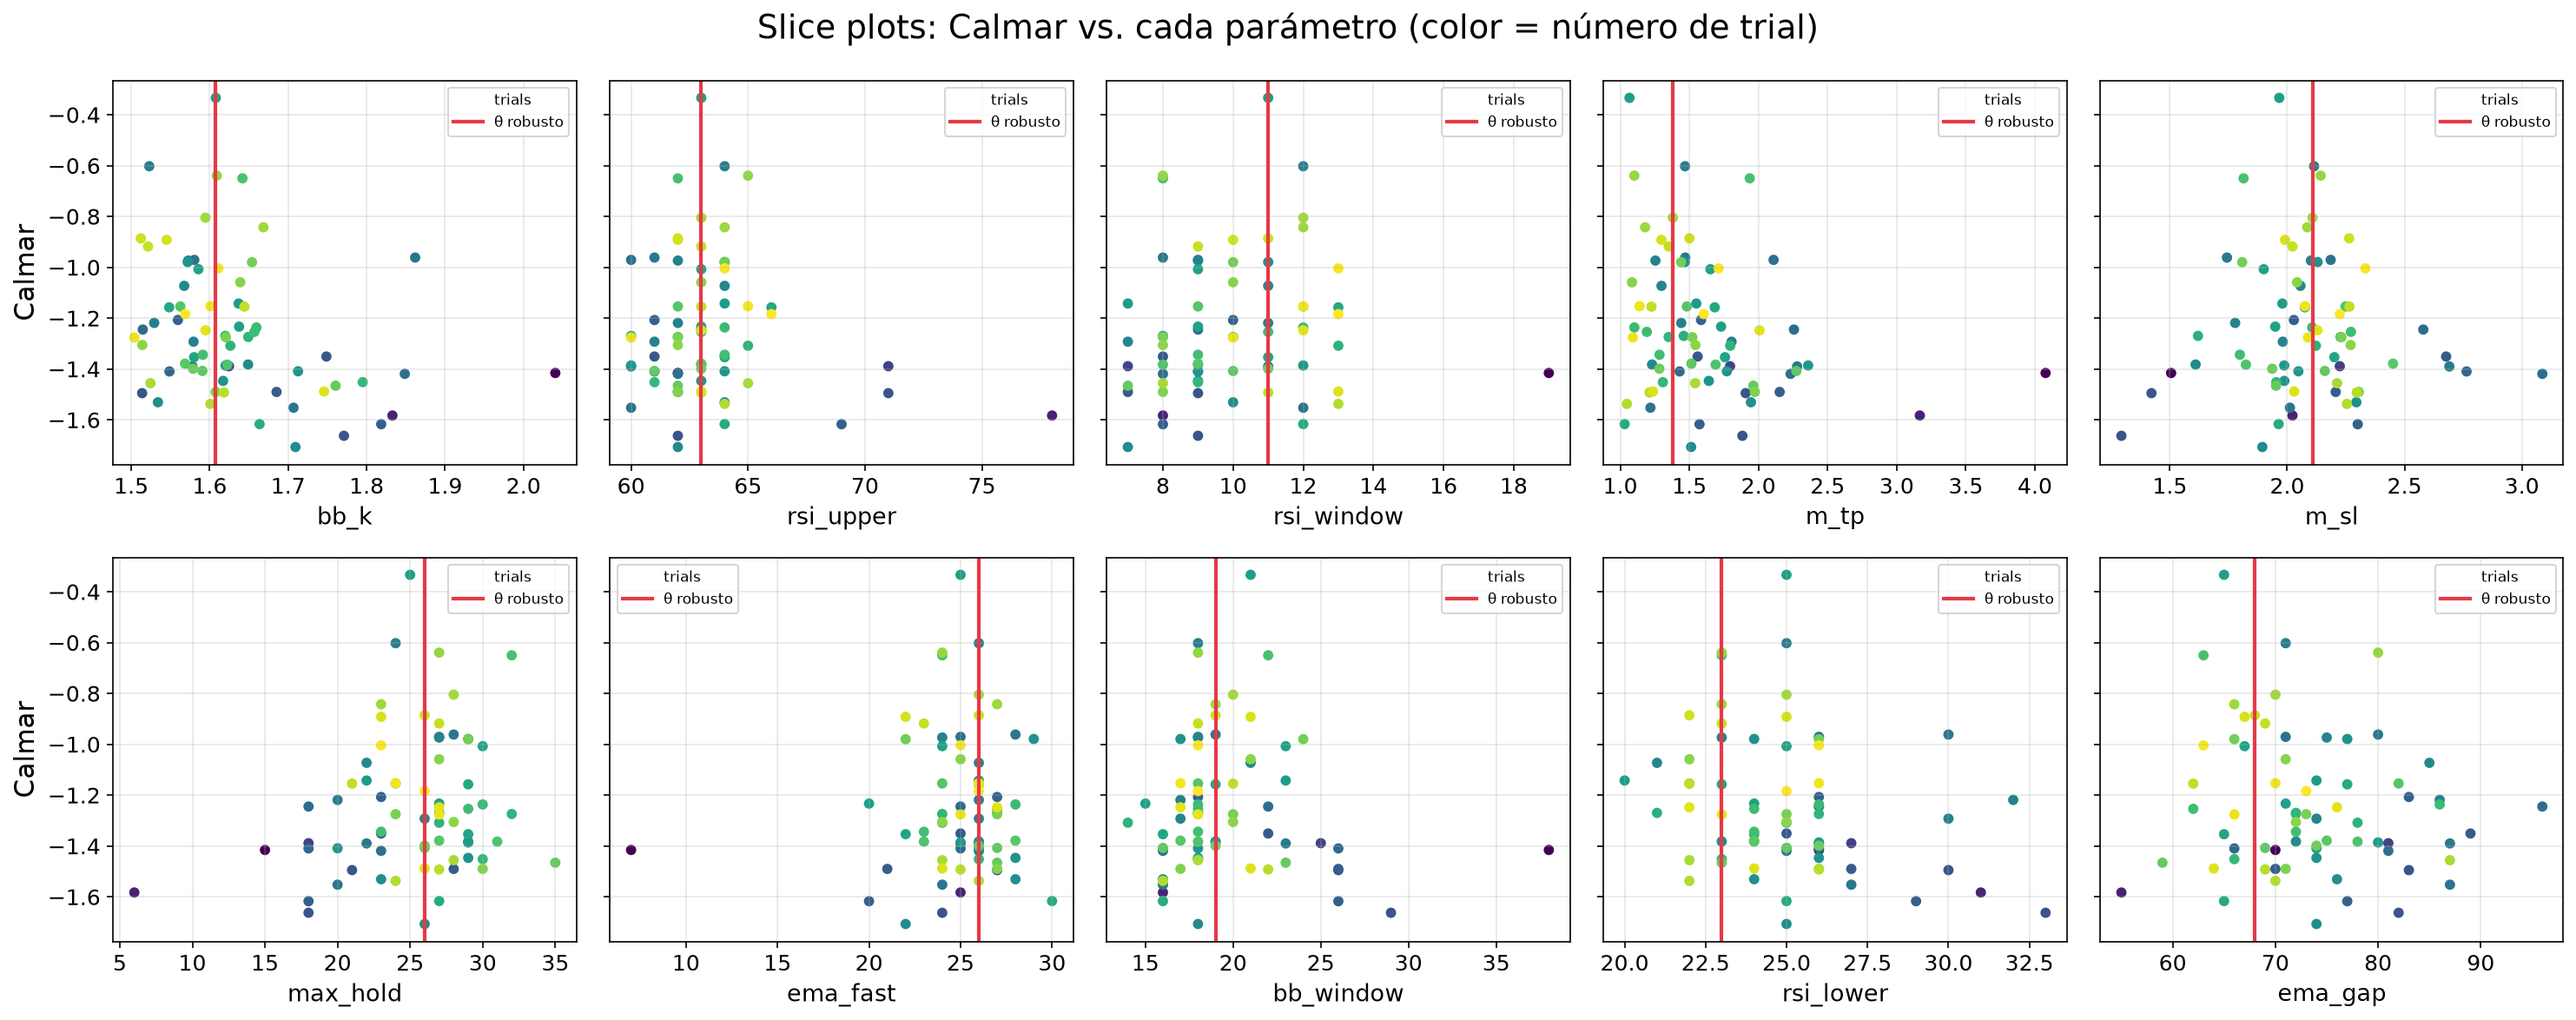

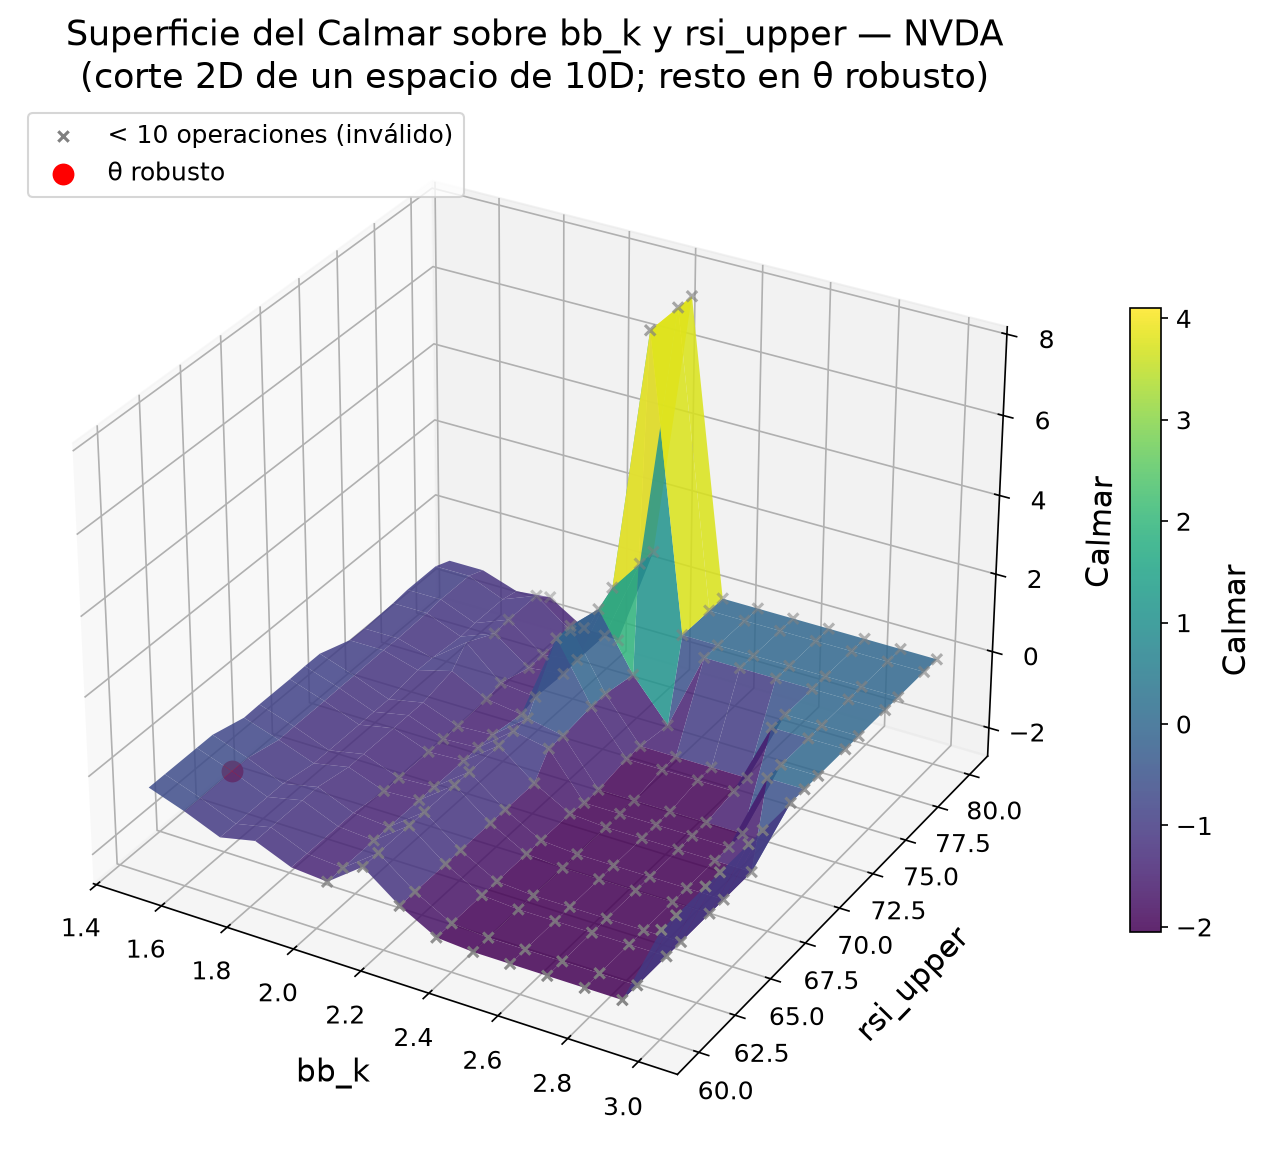

In [7]:
display(read("variantes_comparacion.csv"))
display(read("metricas_conjuntos.csv"))
for f in ["13_rolling_vs_anclado.png", "01_valor_portafolio.png", "02_drawdown.png", "03a_retornos_mensuales_anuales.png", "03b_retornos_trimestrales.png", "12a_optuna_historia.png", "12b_optuna_importancia.png", "12c_optuna_slices.png", "12d_optuna_superficie_3d.png"]:
    show(f)

## 6. Robustez

,regla,nivel,activo,retorno_total,cagr,sharpe,mdd,calmar,pnl_neto,n_operaciones,turnover_anual,costos_totales,pnl_bruto
0,2 de 3,portafolio,portafolio,-0.055324,-0.006832,-0.097364,0.158058,-0.043226,-55323.88073,624,5.273725,104402.23380,49078.353050
7,solo EMA,portafolio,portafolio,0.100411,0.011593,0.270002,0.090107,0.128655,100411.11700,1424,6.854015,145064.42840,245475.545400
14,solo RSI,portafolio,portafolio,-0.074607,-0.009297,-0.268673,0.094069,-0.098827,-74607.41292,827,4.037578,80669.49087,6062.077952
21,solo Bollinger,portafolio,portafolio,-0.073892,-0.009204,-0.257041,0.107544,-0.085587,-73892.45051,863,4.139985,82697.36662,8804.916109


,tipo,parametro,calmar_base,calmar_min,calmar_max,caida_relativa_max,cambio_relativo_max,cambia_signo,veredicto
0,parametro,ema_fast,-0.01219,-0.025446,0.024873,0.053025,0.148250,False,meseta
1,parametro,ema_gap,-0.01219,-0.035481,0.007822,0.093165,0.093165,False,meseta
2,parametro,rsi_window,-0.01219,-0.029373,0.019584,0.068735,0.127096,False,meseta
3,parametro,rsi_lower,-0.01219,-0.027991,-0.004583,0.063206,0.063206,False,meseta
4,parametro,rsi_upper,-0.01219,-0.058539,0.162048,0.185399,0.696951,False,pico
5,parametro,bb_window,-0.01219,-0.037755,0.001284,0.102260,0.102260,False,meseta
6,parametro,max_hold,-0.01219,-0.031907,-0.002752,0.078871,0.078871,False,meseta
7,parametro,bb_k,-0.01219,-0.092105,0.097325,0.319661,0.438060,False,meseta
8,parametro,m_sl,-0.01219,-0.038522,0.006232,0.105329,0.105329,False,meseta
9,parametro,m_tp,-0.01219,-0.060686,0.001206,0.193986,0.193986,False,meseta


comision_oficial                  0.00125
comision_equilibrio              0.000602
equilibrio_fuera_de_rango           False
margen_puntos                   -0.000648
margen_multiplo                  0.481213
turnover_anual                   5.273725
costo_anual_por_rotacion         0.013184
costos_totales_oficial       104402.23378
pnl_bruto_oficial            49078.353053
pnl_neto_oficial            -55323.880727
dtype: object

,escenario,retorno_total,cagr,sharpe,mdd,calmar,pnl_neto,n_operaciones,turnover_anual,costos_totales,pnl_bruto,delta_cagr,delta_calmar
0,oficial (solo comisión),-0.055324,-0.006832,-0.097364,0.158058,-0.043226,-55323.88073,624,5.273725,104402.2338,49078.35305,0.000000,0.000000
1,realista (spread+borrow+impacto),-0.074531,-0.009287,-0.142307,0.160467,-0.057874,-74531.39317,624,5.273657,122629.1254,48097.73219,-0.002455,-0.014647
2,slippage 2.5 bps,-0.075791,-0.009449,-0.145337,0.160547,-0.058857,-75790.87482,624,5.272878,123900.6837,48109.80891,-0.002617,-0.015630
3,slippage 5 bps,-0.095807,-0.012058,-0.193236,0.166838,-0.072276,-95807.20232,624,5.272030,142962.4863,47155.28397,-0.005226,-0.029050
4,slippage 10 bps,-0.134528,-0.017253,-0.288801,0.182175,-0.094708,-134527.95570,624,5.270337,179815.2322,45287.27652,-0.010421,-0.051481
5,slippage 15 bps,-0.171564,-0.022417,-0.384025,0.212044,-0.105719,-171564.07810,624,5.268645,215036.4309,43472.35283,-0.015585,-0.062493
6,slippage 20 bps,-0.206990,-0.027550,-0.478879,0.241534,-0.114063,-206990.00780,624,5.266954,248698.6243,41708.61649,-0.020718,-0.070837


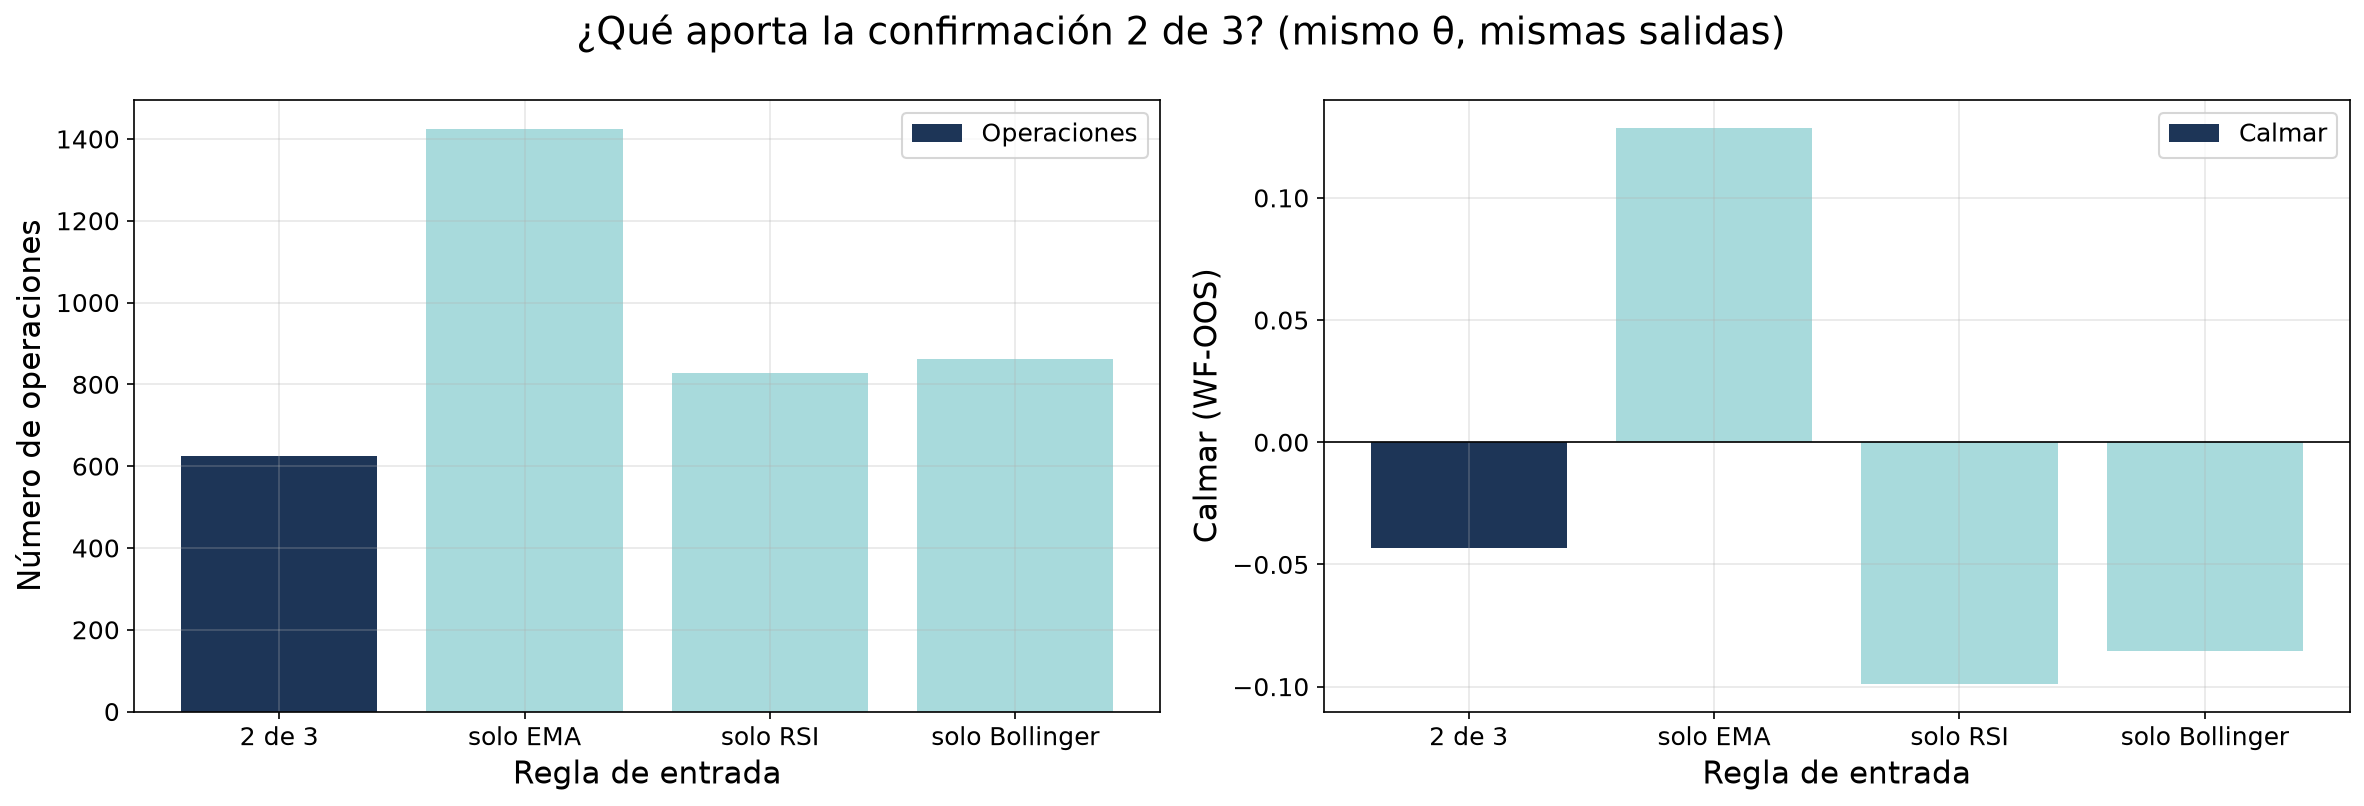

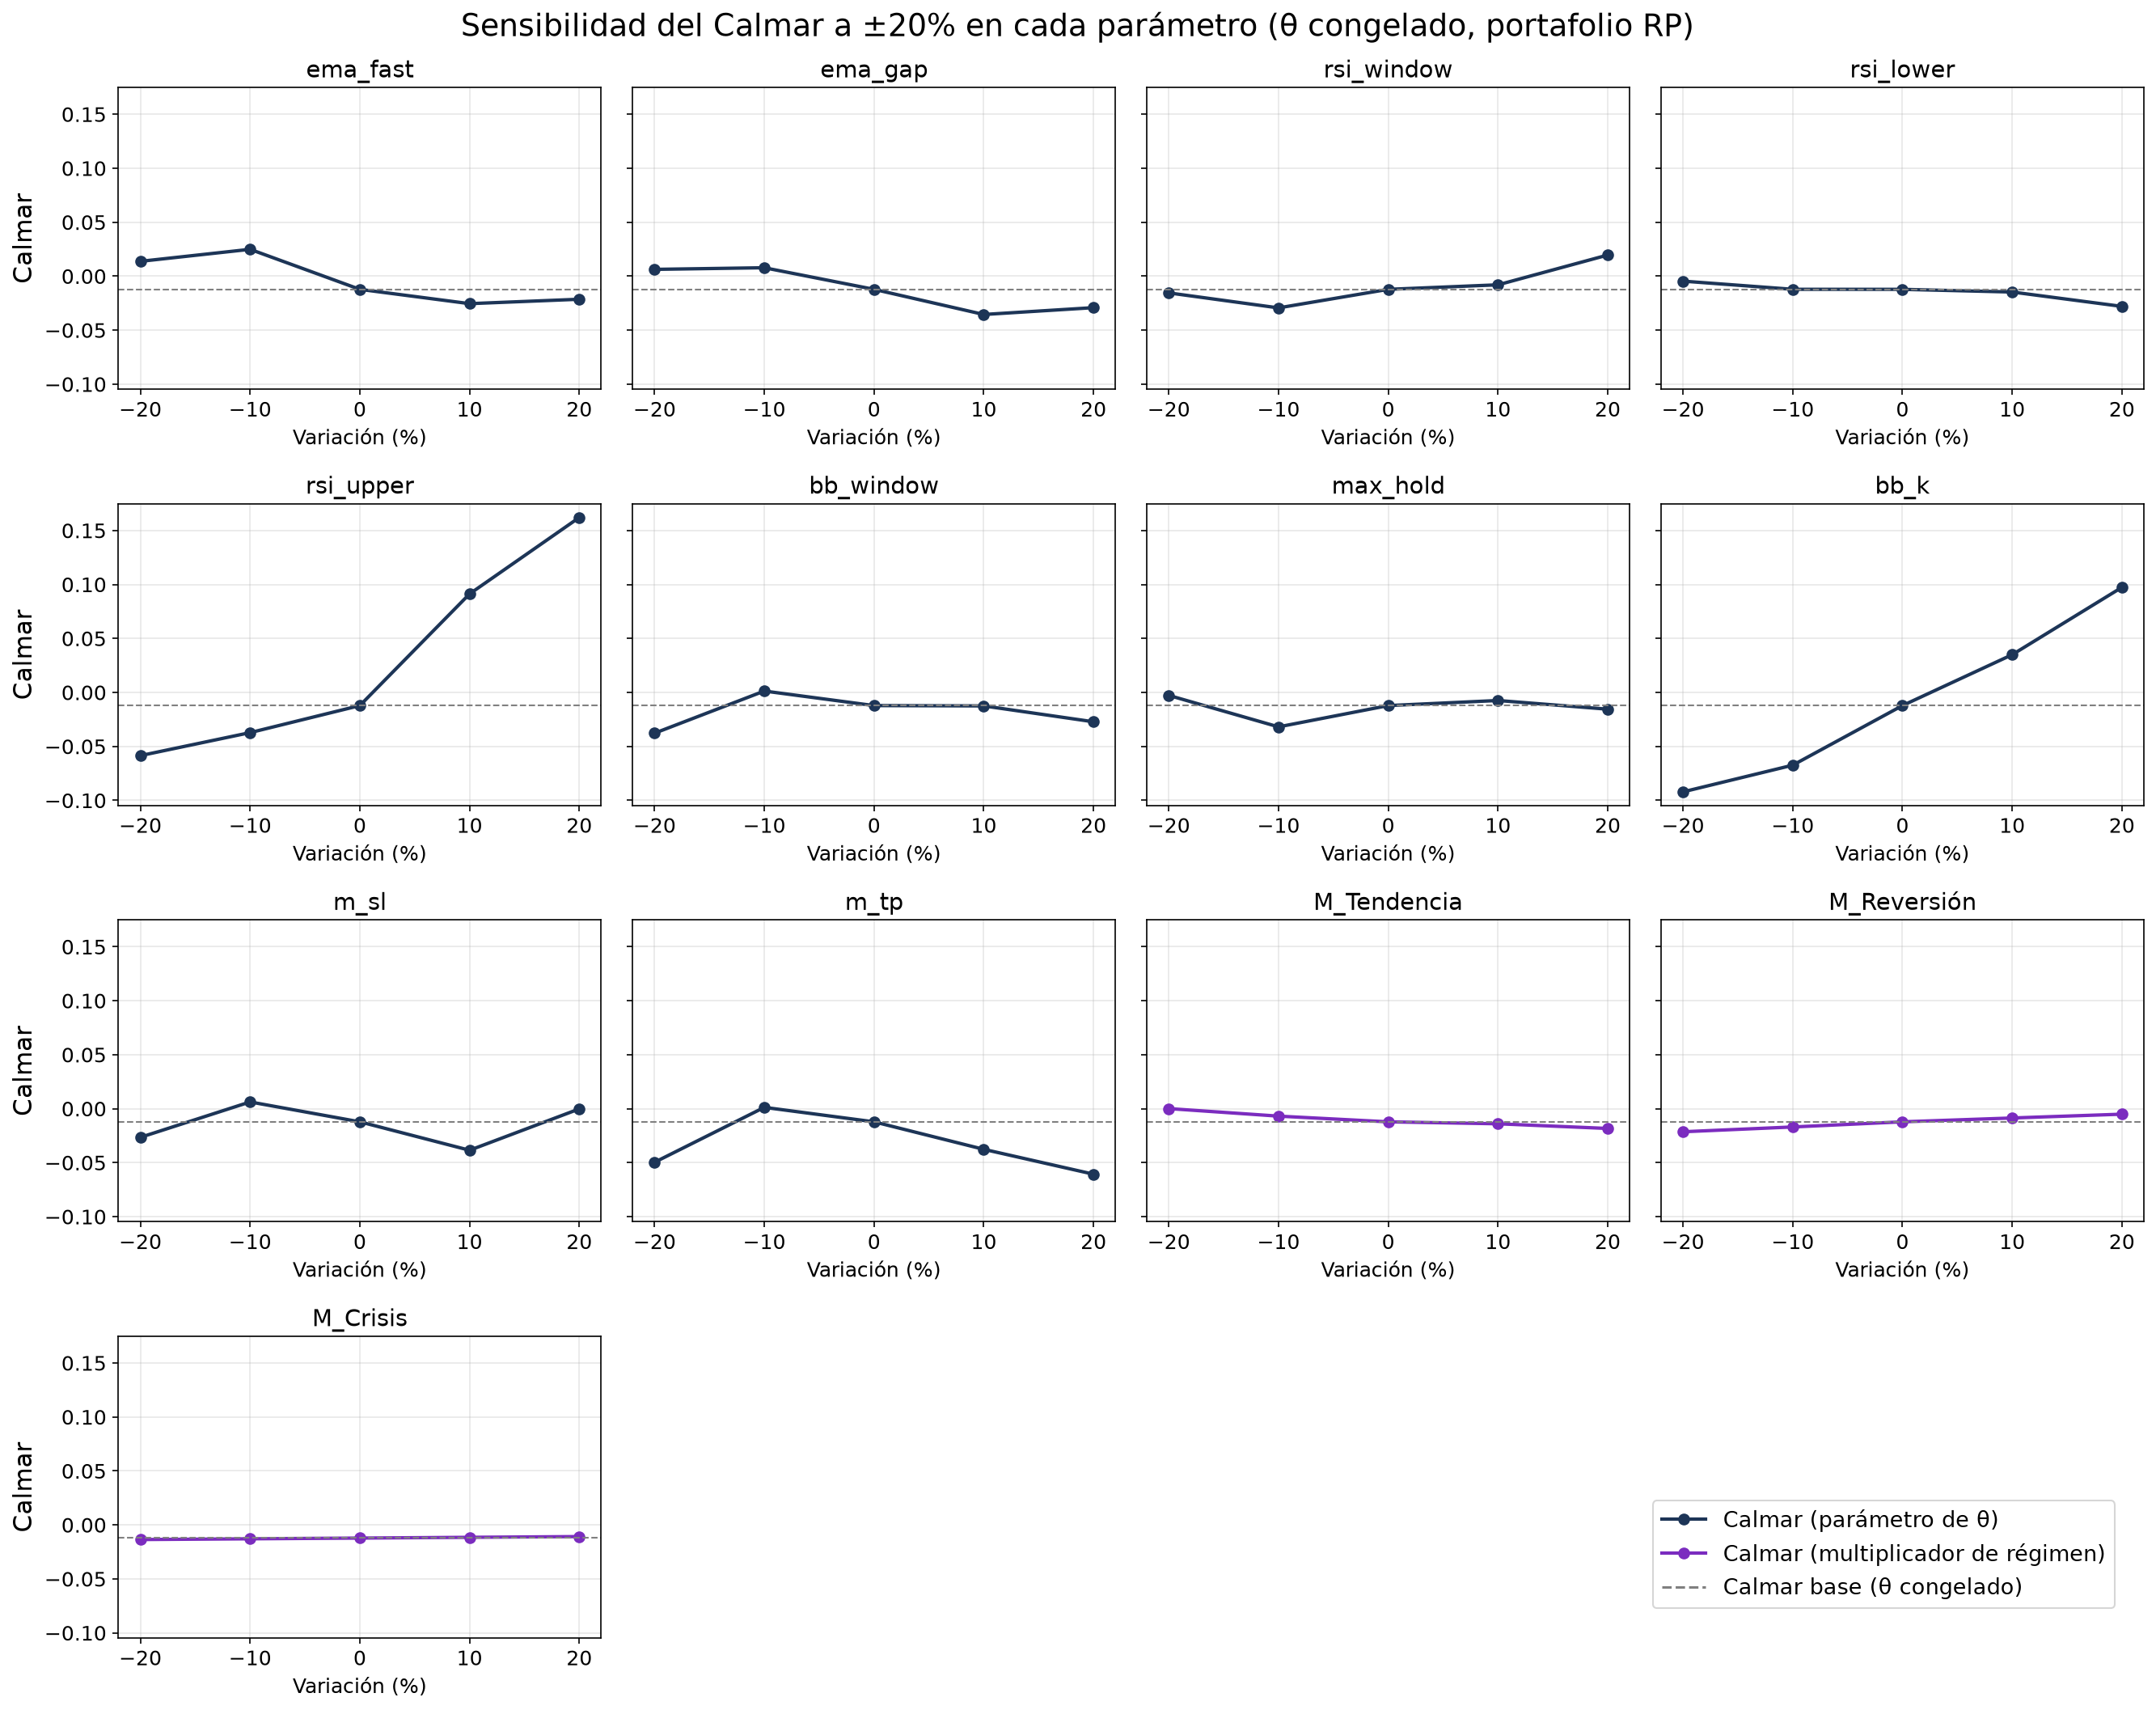

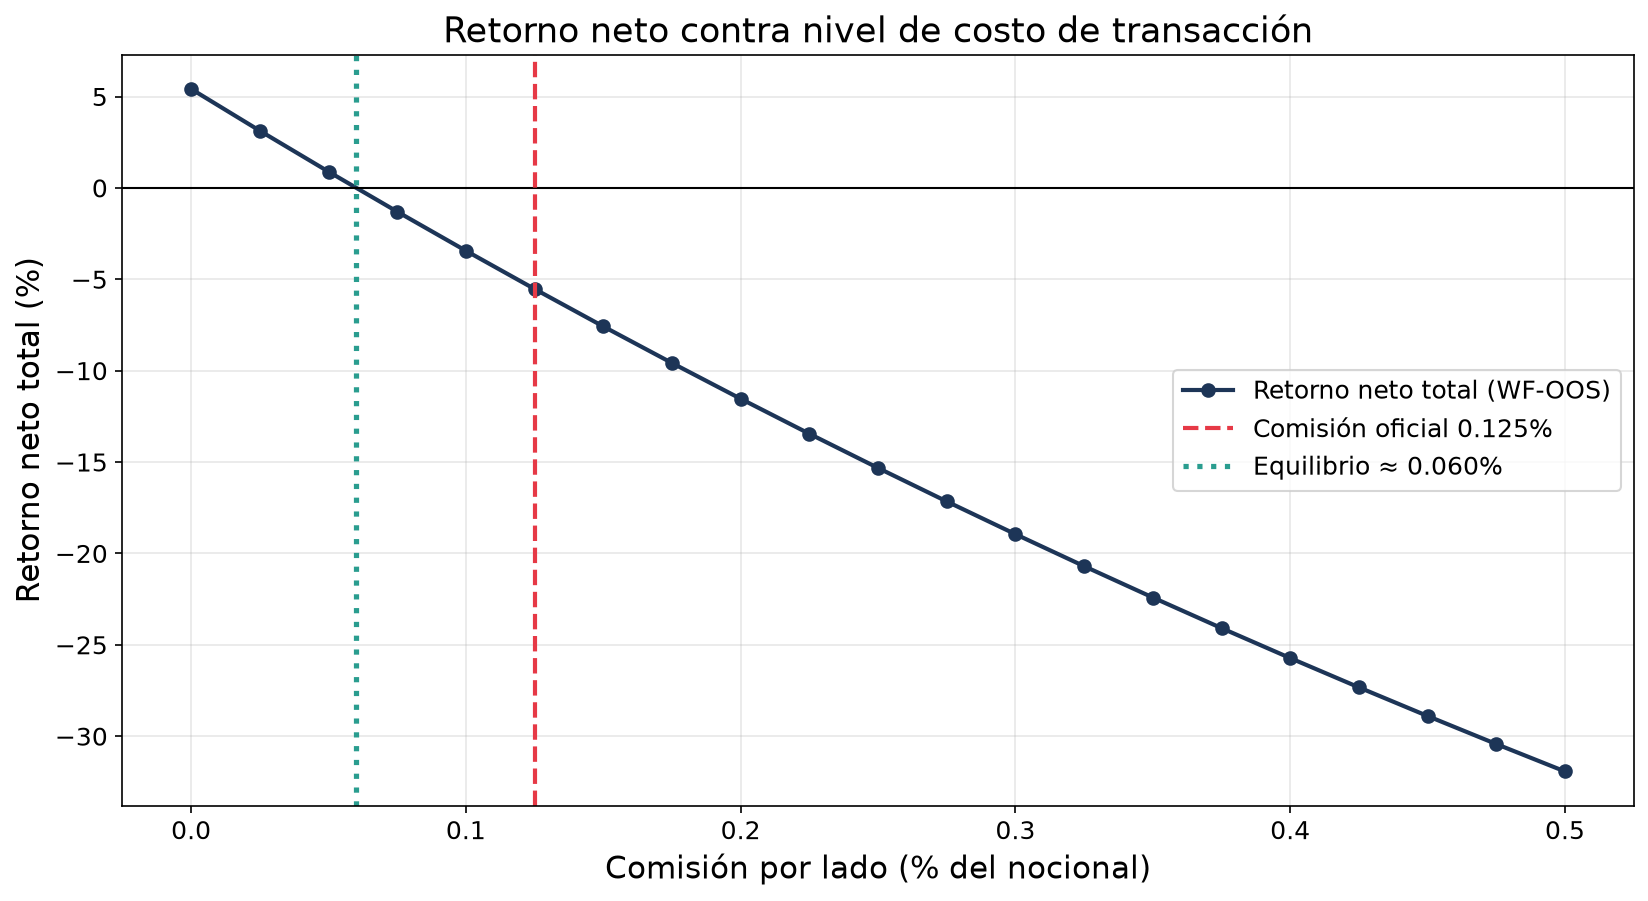

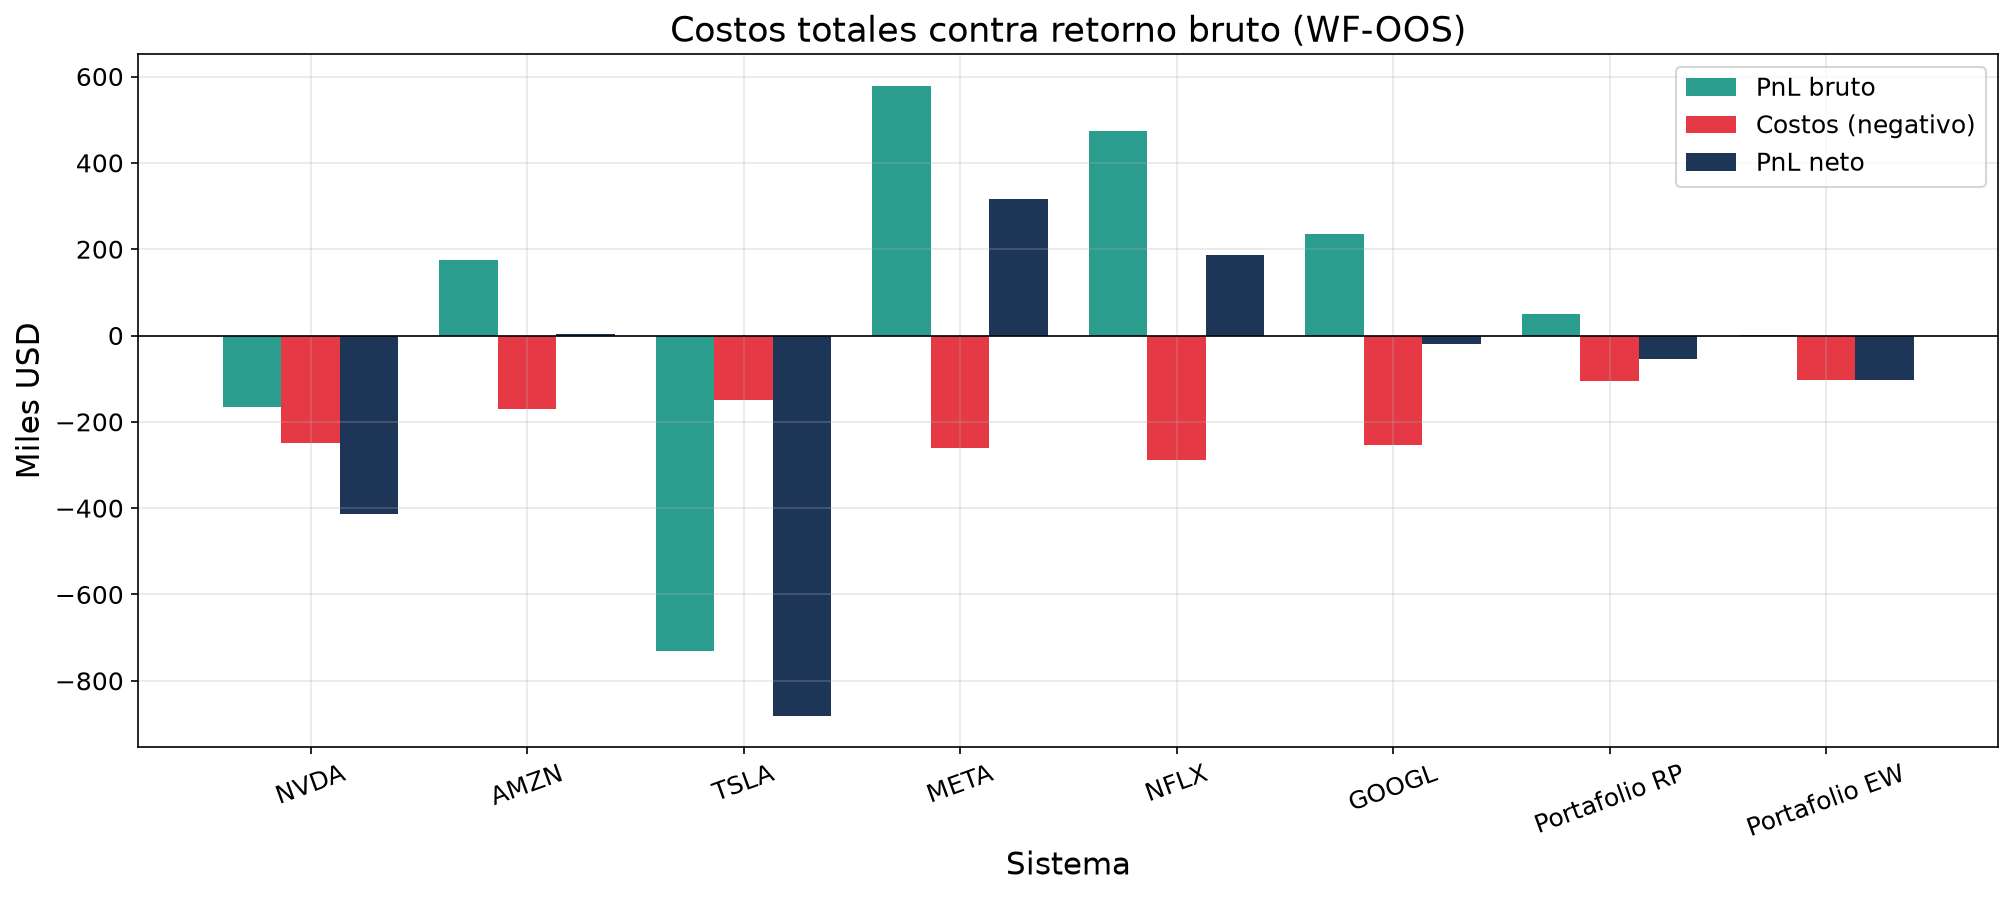

In [8]:
display(read("indicador_unico.csv").query("nivel == 'portafolio'"))
display(read("sensibilidad_veredicto.csv"))
display(pd.Series(read_json("costos_equilibrio.json")))
display(read("costos_ejecucion_wf_oos.csv"))
for f in ["08_indicador_unico.png", "04_sensibilidad.png", "05_curva_costos.png", "11_costos_vs_bruto.png"]:
    show(f)

## 7. TEST (sistema congelado, una sola corrida)

In [9]:
if (RES / "metricas_test.csv").exists():
    display(read("metricas_test.csv"))
    display(read("metricas_por_regimen_test.csv"))
    show("03c_retornos_mensuales_test.png")
else:
    display(Markdown("**TEST: Pendiente.** Se corre una sola vez con `python main.py --stage test` "
                     "con el árbol de git limpio."))

**TEST: Pendiente.** Se corre una sola vez con `python main.py --stage test` con el árbol de git limpio.

## 8. Respuestas a las preguntas

Las respuestas completas, con cifras leídas de `docs/resultados/`, están en `docs/borrador_reporte.md` (sección 13) y en `docs/reporte.pdf`.

In [10]:
text = (config.DOCS_DIR / "borrador_reporte.md").read_text(encoding="utf-8")
start = text.index("## 13.")
display(Markdown(text[start:text.index("## 14.")]))

## 13. Respuestas a las preguntas

**1. ¿Qué aporta la regla 2 de 3 frente a un solo indicador?** Con 2 de 3 el portafolio hizo 624 operaciones con Calmar -0.04; con un solo indicador, entre 827 y 1,424 operaciones y Calmar entre -0.10 y 0.13. La confirmación reduce el número de operaciones frente al promedio de los indicadores solos (1,038). En Calmar no supera a todos: el mejor indicador solo es solo EMA (0.13).

**2. ¿Cuánto se degrada de train a test en el walk-forward?** El CAGR in-sample promedio por ventana fue 10.5% y el CAGR WF-OOS -0.7%: WFE = -0.07 (Calmar: 6.26 → -0.04, WFE = -0.01). Con train anclado la WFE es -0.31. Sobrevive menos de la mitad de la ventaja in-sample: la mayor parte es ajuste a la muestra. TEST: [PENDIENTE: test].

**3. ¿Qué tan sensible es a ±20%?** Con rsi_upper el Calmar cambia más de 50% o cambia de signo (pico); el resto (12 de 13) se comporta como meseta. El mayor cambio relativo fue 69.7% (rsi_upper) y la mayor caída 32.0% (bb_k).

**4. ¿A qué costo deja de ser rentable?** Ya no es rentable con la comisión oficial: el PnL neto cruza cero en ≈ 0.060% por lado, por debajo de 0.125% (margen de -0.065 puntos porcentuales; el equilibrio es 0.48 veces la comisión oficial). Antes de costos la estrategia gana $49,078, pero los costos ($104,402) se comen toda la ganancia y dejan un PnL neto de −$55,324. Con un turnover de 5.3 veces al año, la comisión oficial cuesta ≈ 1.3% del capital por año.

**5. ¿El desempeño difiere significativamente entre regímenes?** Portafolio RP — Tendencia: -3.4% anualizado (IC 95% diario [-4.5, 1.6] pb), Reversión: 2.4% anualizado (IC 95% diario [-1.1, 2.9] pb), Crisis: 0.1% anualizado (IC 95% diario [-2.0, 1.5] pb). Kruskal-Wallis p = 0.094: no hay evidencia de diferencias significativas al 5% (los intervalos se traslapan). Aun así la capa de régimen aporta control de riesgo: en Crisis la exposición baja a 30% y solo se abren señales 3 de 3 (solo 27 entradas en Crisis en WF-OOS), y los parámetros se adaptan al tipo de mercado.

**6. ¿Risk Parity mejora el Calmar frente a pesos iguales?** WF-OOS con las mismas señales, costos y rebalanceo: Calmar RP -0.04 vs. EW -0.07 (RP naïve -0.02); MDD 15.8% vs. 18.5% (15.4%); CAGR -0.7% vs. -1.3% (-0.4%). La mayor contribución al riesgo de un solo activo es en promedio 71.4% con EW, 67.3% con RP naïve y 67.8% con RP. RP mejora el Calmar frente a EW sin sacrificar CAGR; su turnover es 5.27 vs. 5.31 veces al año. En esta muestra la RP naïve tuvo un Calmar ligeramente mayor que la optimizada (-0.02 vs. -0.04). La diferencia con RP naïve es pequeña, consistente con que los seis activos tienen correlaciones parecidas (la naïve es exacta si todas son iguales). La mejora viene de controlar el drawdown, no de generar retorno: el Calmar es negativo.

**7. Tres limitaciones para operar con capital real.** (i) *Ejecución*: se supone llenado completo al open o al nivel exacto de SL/TP, sin impacto ni rechazos (ver sección 14); los stops intradía en la práctica sufren slippage. (ii) *Universo y sesgo de selección*: seis mega-cap tech muy correlacionadas, elegidas sabiendo que fueron ganadoras; la diversificación real es limitada y el resultado no se generaliza a otros sectores. (iii) *Estabilidad estadística*: con 460,800 configuraciones probadas y regímenes que cambian, el θ óptimo es inestable entre ventanas; además, la disponibilidad y el costo de préstamo de los cortos no están garantizados.


